In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/indian_stock_factor_dataset_builder.py
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/fmcg_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/pharma_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/energy_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/banking_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/it_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/master_dataset.csv
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/.gitignore
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/pyvenv.cfg
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/Scripts/deactivate.bat
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/Scripts/activate.bat
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/Scripts/Activate.ps1
/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/.venv/Scripts/pip3.14.exe
/kaggle

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "/kaggle/input/datasets/rick2324/etf-datasheet/etf 2.0/master_dataset.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(160893, 39)


,Date,Close,High,Low,Open,Volume,Company,Sector,Return,Log_Return,...,Volatility_of_Volatility,Momentum_of_Momentum,Volatility_Acceleration,Momentum_Acceleration,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,ATR_14
0,2015-01-01,975.650940,983.872214,973.907011,983.872214,366830,TCS.NS,IT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2015-01-02,988.644043,993.051729,977.586555,977.739829,925740,TCS.NS,IT,0.013317,0.013229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2015-01-05,973.619324,996.481758,967.640166,989.237860,1754242,TCS.NS,IT,-0.015197,-0.015314,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2015-01-06,937.725647,969.346003,935.195981,969.346003,2423784,TCS.NS,IT,-0.036866,-0.037563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2015-01-07,926.648926,950.201282,922.720336,946.694335,2636332,TCS.NS,IT,-0.011812,-0.011883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [3]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company', 'Sector', 'Return', 'Log_Return', 'Volume_Change', 'High_Low_Range', 'Open_Close_Change', 'Dollar_Volume', 'Volatility_20D', 'Volatility_60D', 'Volatility_120D', 'Momentum_1M', 'Momentum_3M', 'Momentum_6M', 'Momentum_12M', 'MA_20', 'MA_50', 'MA_200', 'Price_to_MA20', 'Price_to_MA50', 'Price_to_MA200', 'Sharpe_20D', 'Sharpe_60D', 'Volatility_of_Volatility', 'Momentum_of_Momentum', 'Volatility_Acceleration', 'Momentum_Acceleration', 'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Upper', 'Bollinger_Lower', 'ATR_14']


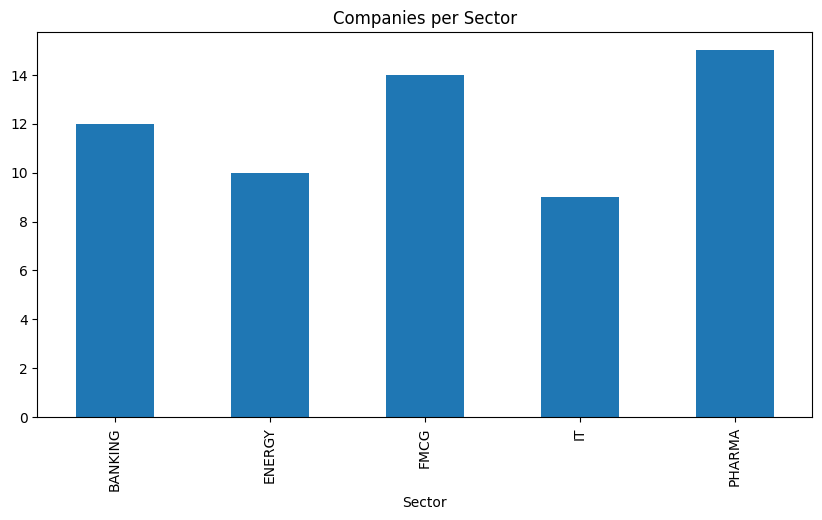

In [4]:
company_counts = df.groupby("Sector")["Company"].nunique()

company_counts.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Companies per Sector")
plt.show()

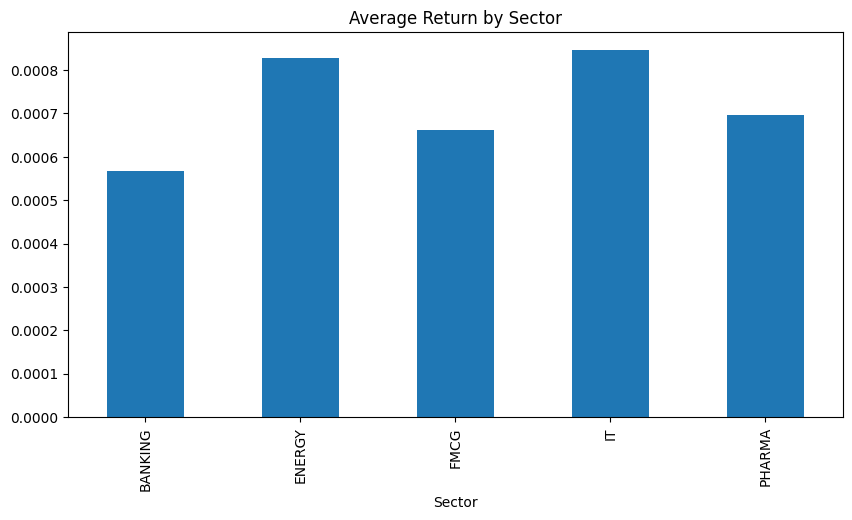

In [5]:
df.groupby("Sector")["Return"].mean().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Return by Sector")
plt.show()

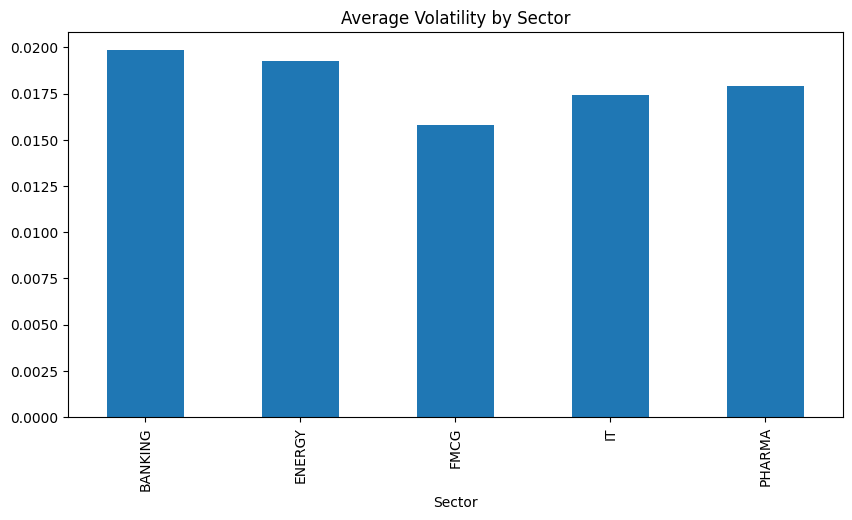

In [6]:
df.groupby("Sector")["Volatility_20D"].mean().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Volatility by Sector")
plt.show()

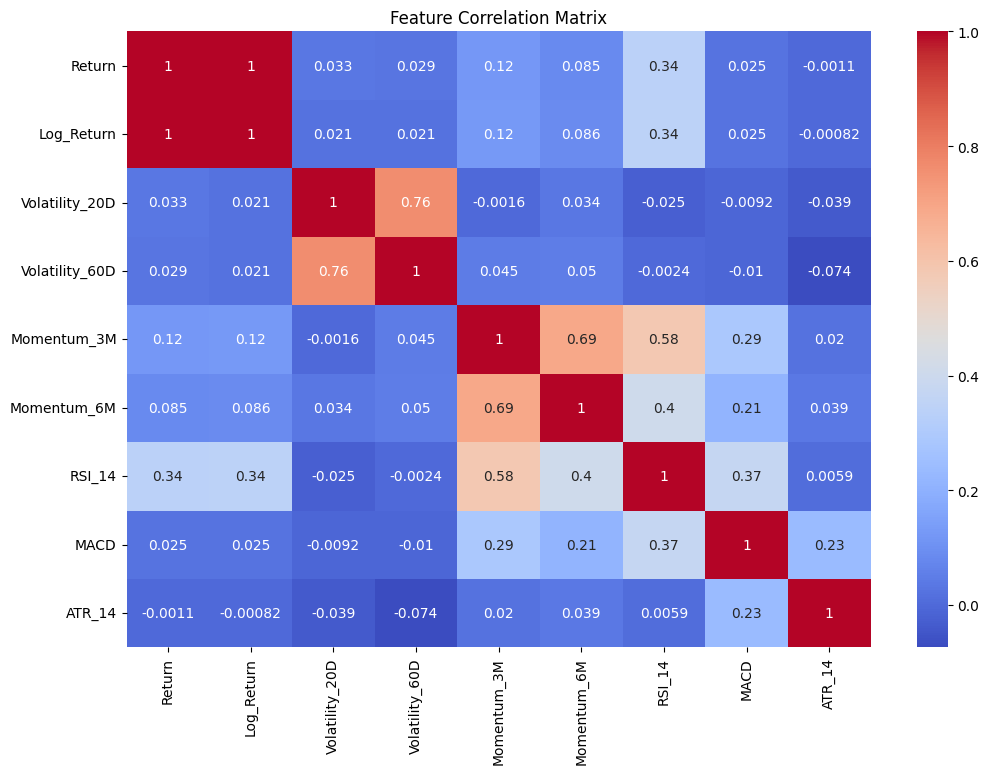

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Return",
    "Log_Return",
    "Volatility_20D",
    "Volatility_60D",
    "Momentum_3M",
    "Momentum_6M",
    "RSI_14",
    "MACD",
    "ATR_14"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

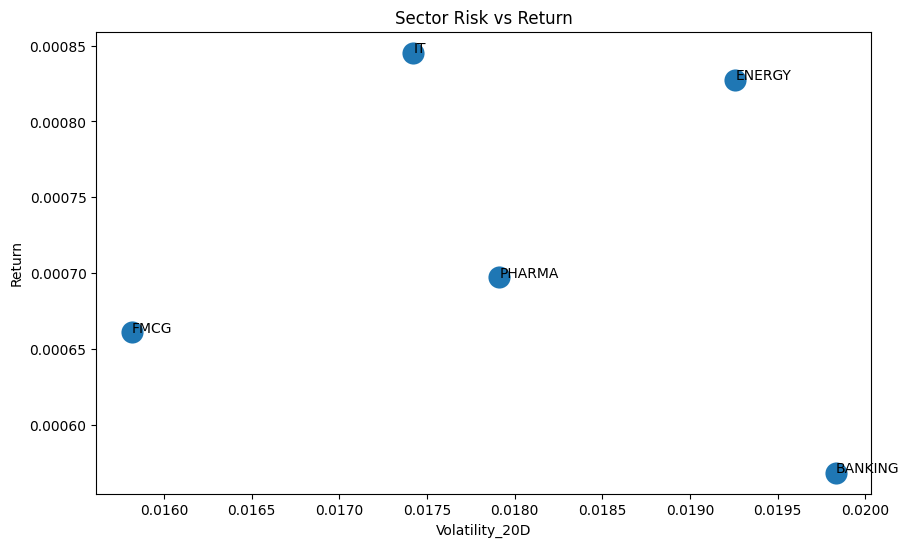

In [8]:
risk_return = (

    df.groupby("Sector")

    .agg({
        "Return":"mean",
        "Volatility_20D":"mean"
    })

)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=risk_return,
    x="Volatility_20D",
    y="Return",
    s=300
)

for idx,row in risk_return.iterrows():

    plt.text(
        row["Volatility_20D"],
        row["Return"],
        idx
    )

plt.title("Sector Risk vs Return")
plt.show()

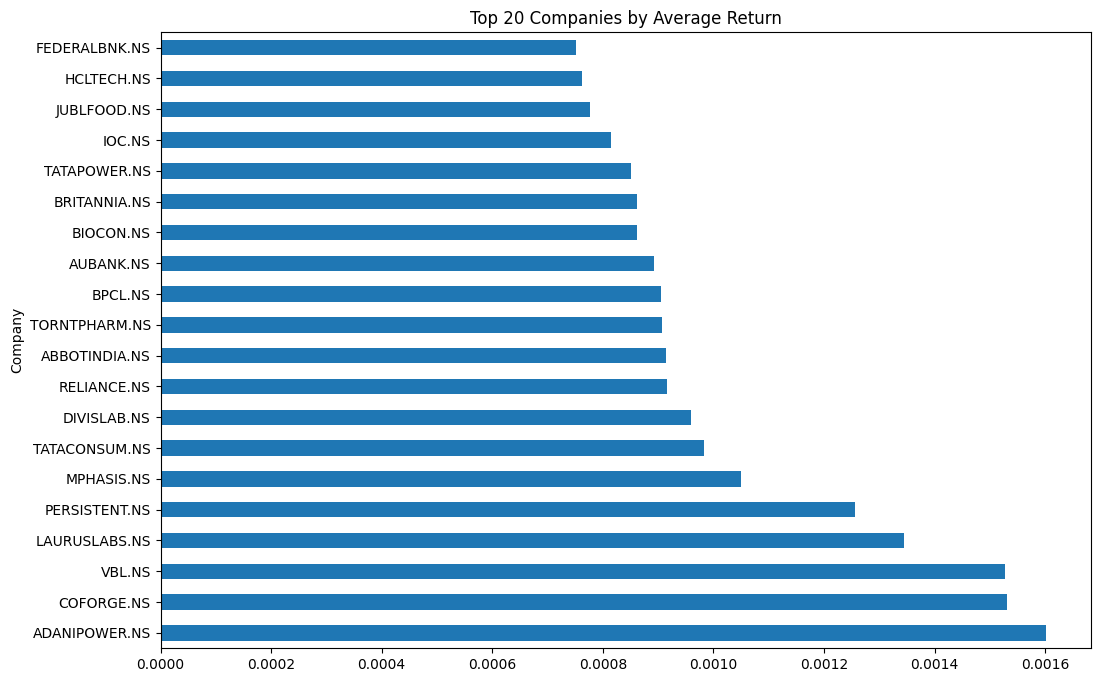

In [9]:
top20 = (

    df.groupby("Company")["Return"]

    .mean()

    .sort_values(ascending=False)

    .head(20)

)

top20.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title(
    "Top 20 Companies by Average Return"
)

plt.show()

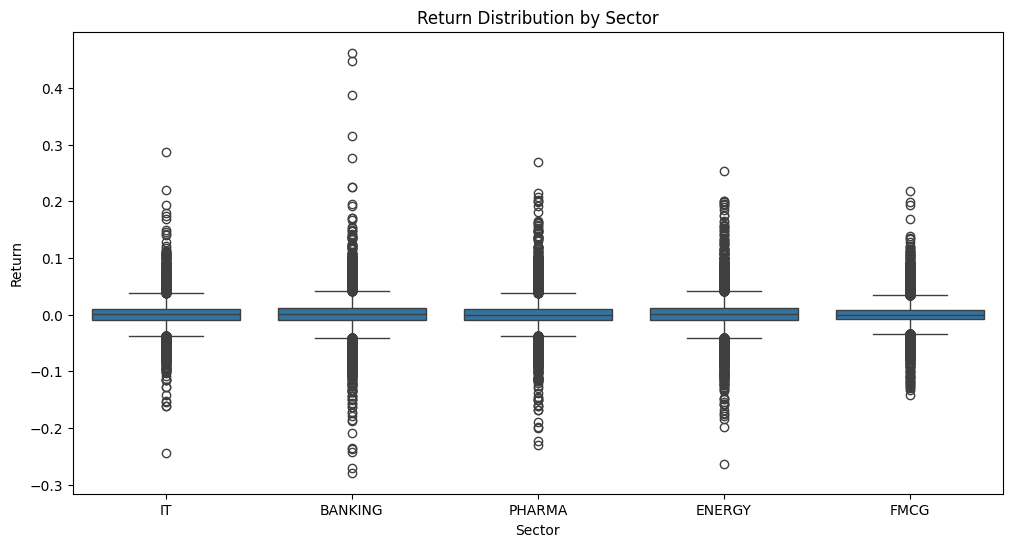

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Sector",
    y="Return"
)

plt.title(
    "Return Distribution by Sector"
)

plt.show()

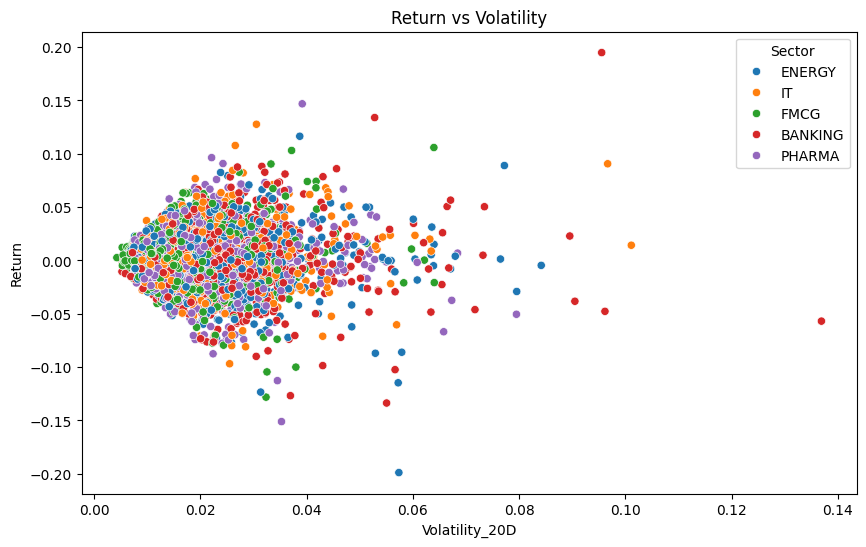

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(10000),
    x="Volatility_20D",
    y="Return",
    hue="Sector"
)

plt.title(
    "Return vs Volatility"
)

plt.show()

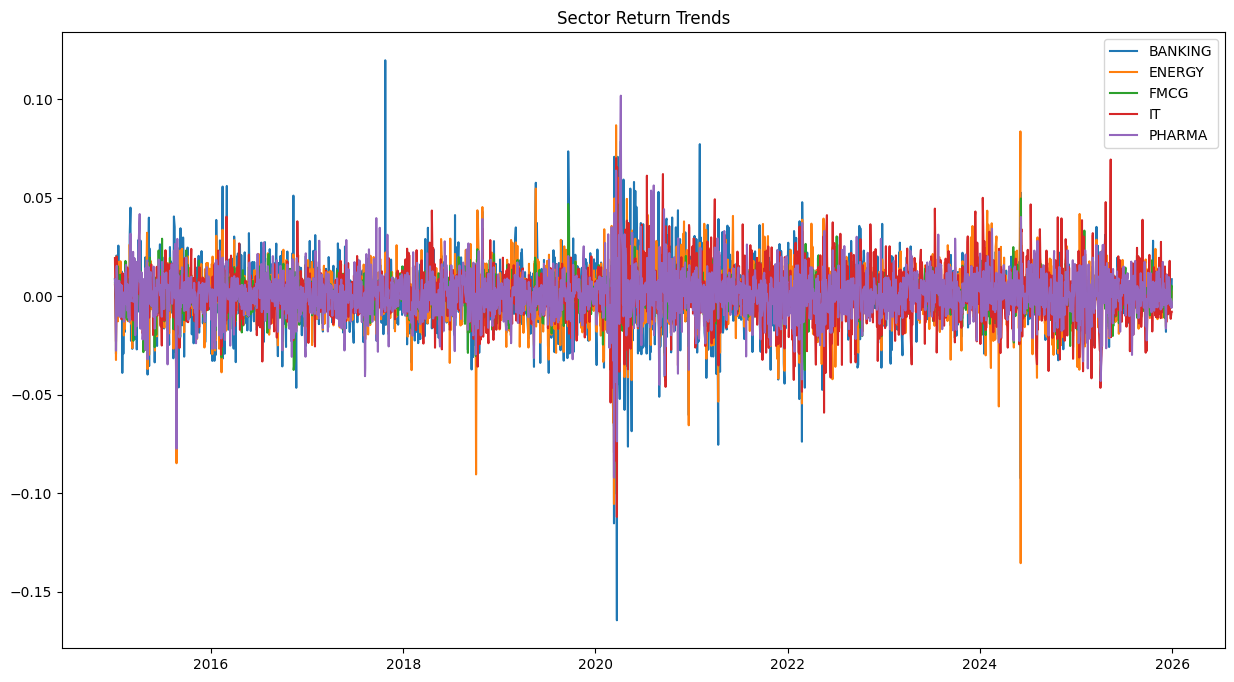

In [13]:
sector_ts = (

    df.groupby(
        ["Date","Sector"]
    )["Return"]

    .mean()

    .reset_index()

)

plt.figure(
    figsize=(15,8)
)

for sector in sector_ts[
    "Sector"
].unique():

    temp = sector_ts[
        sector_ts["Sector"]
        == sector
    ]

    plt.plot(
        temp["Date"],
        temp["Return"],
        label=sector
    )

plt.legend()

plt.title(
    "Sector Return Trends"
)

plt.show()

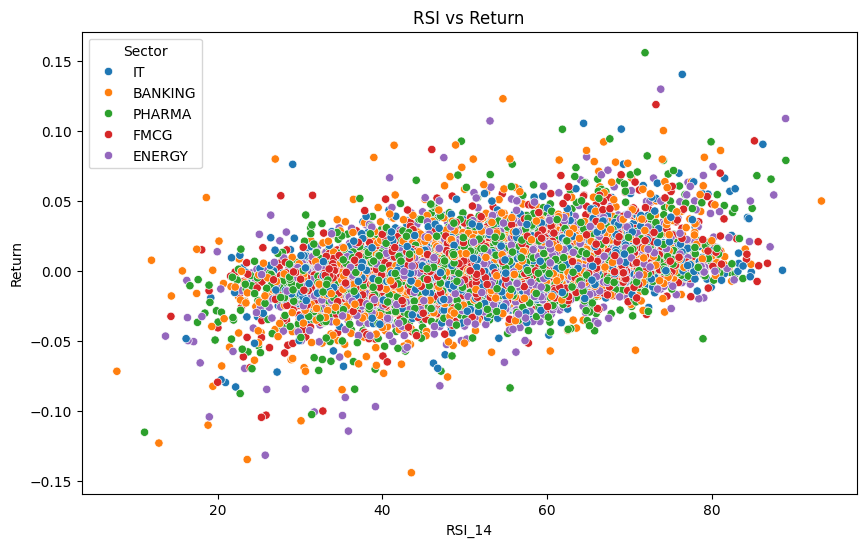

In [14]:
plt.figure(
    figsize=(10,6)
)

sns.scatterplot(
    data=df.sample(10000),
    x="RSI_14",
    y="Return",
    hue="Sector"
)

plt.title(
    "RSI vs Return"
)

plt.show()


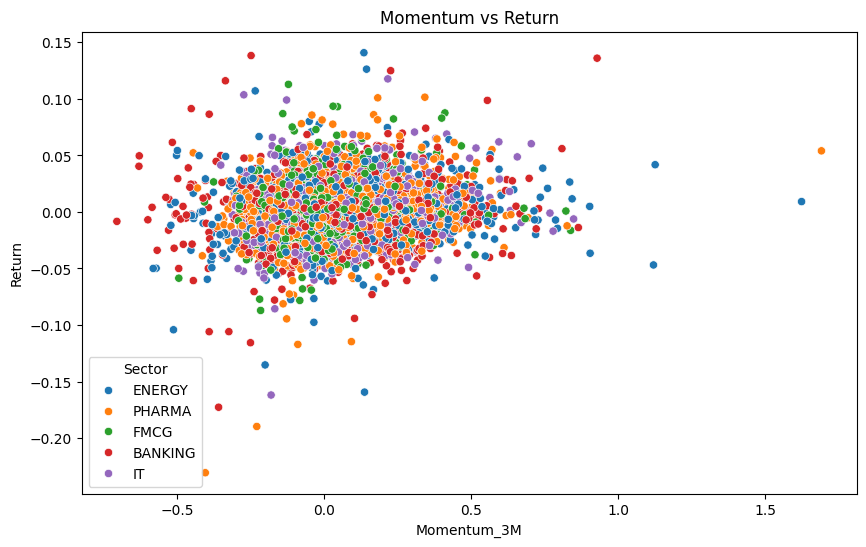

In [15]:
plt.figure(
    figsize=(10,6)
)

sns.scatterplot(
    data=df.sample(10000),
    x="Momentum_3M",
    y="Return",
    hue="Sector"
)

plt.title(
    "Momentum vs Return"
)

plt.show()

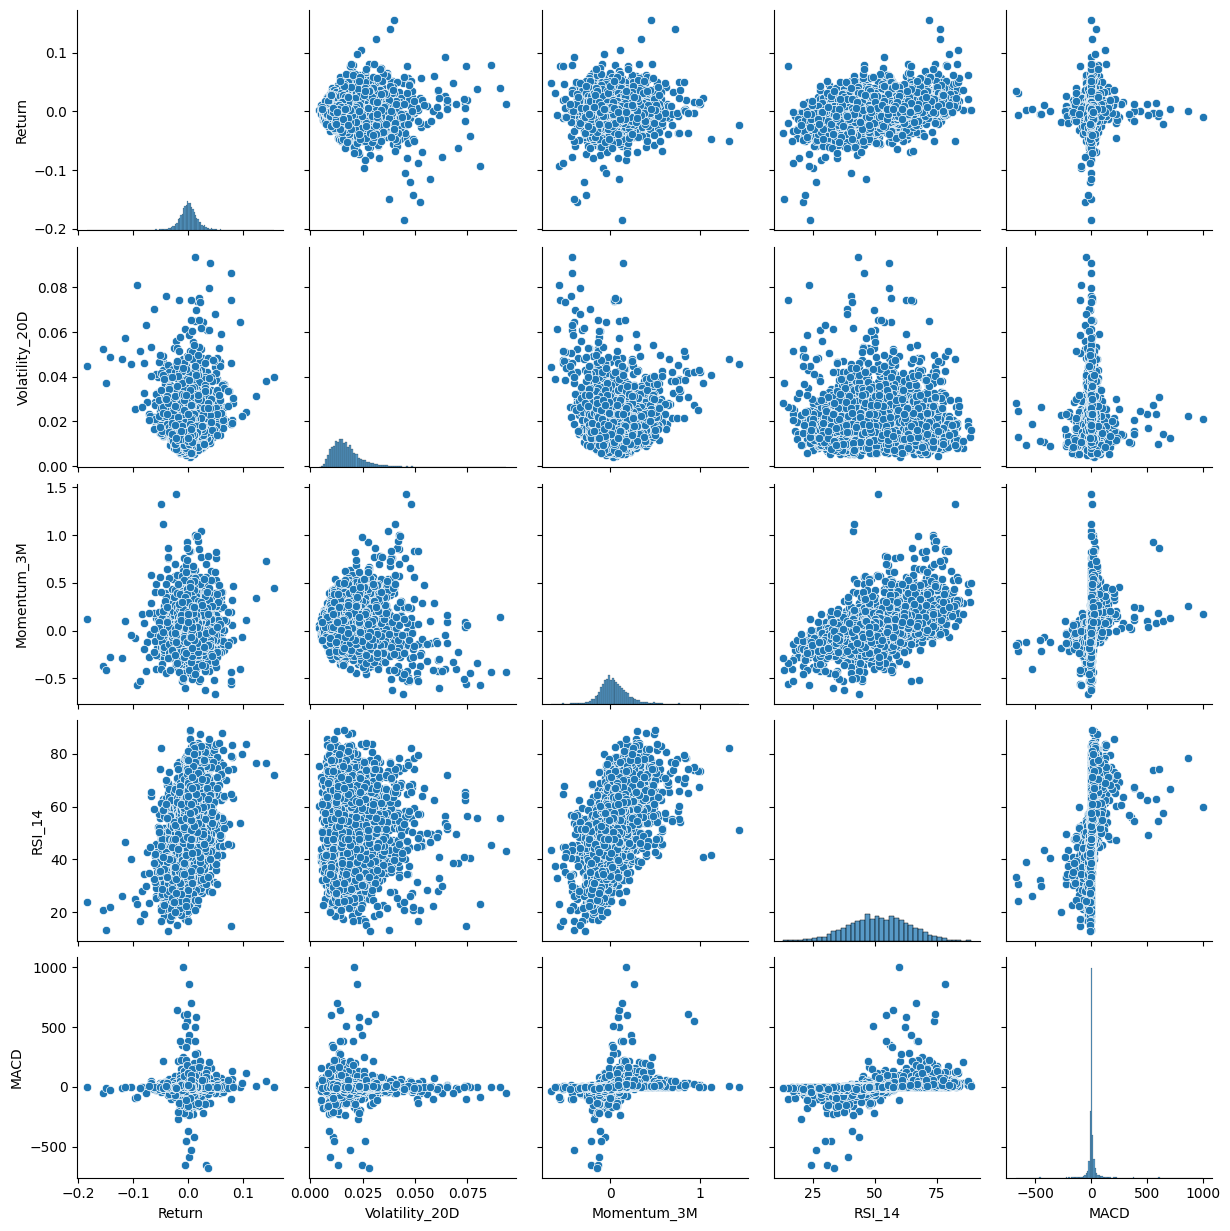

In [16]:
cols = [

    "Return",

    "Volatility_20D",

    "Momentum_3M",

    "RSI_14",

    "MACD"
]

sns.pairplot(
    df[
        cols
    ].dropna()
    .sample(5000)
)

plt.show()

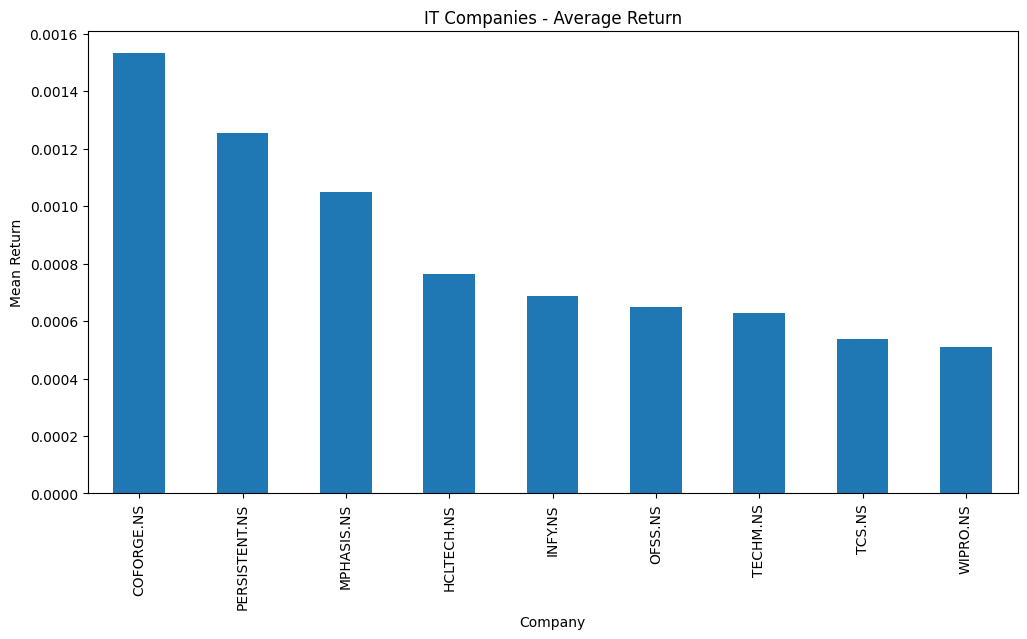

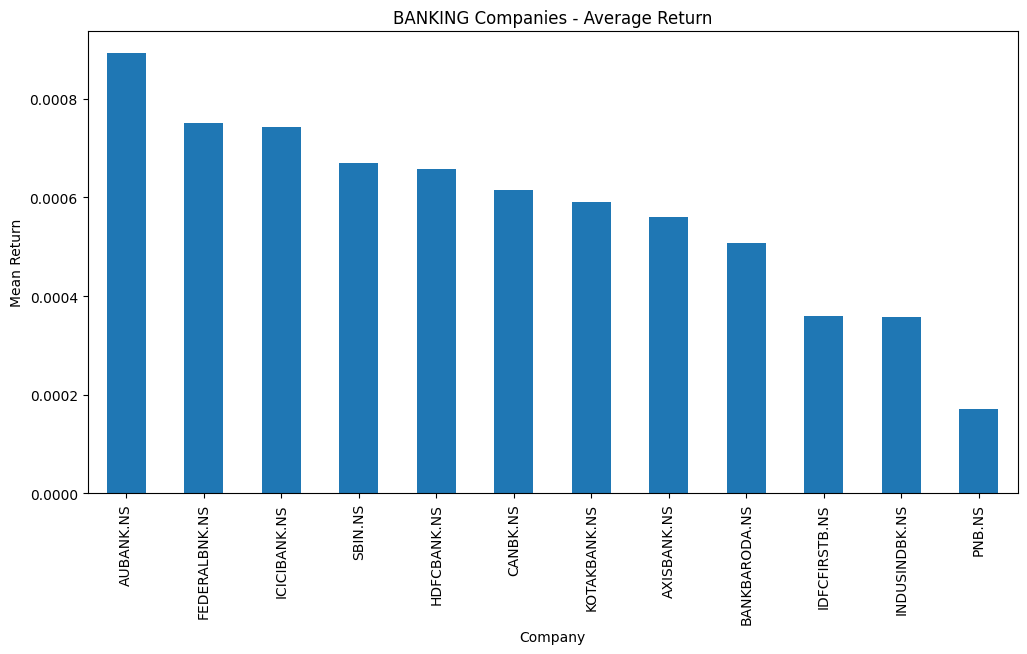

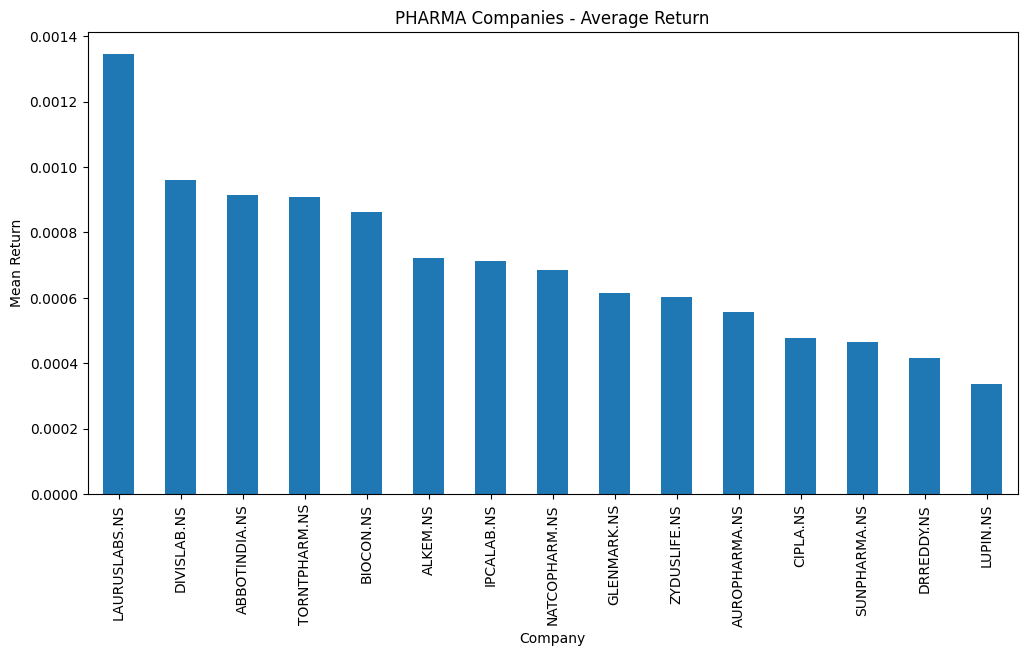

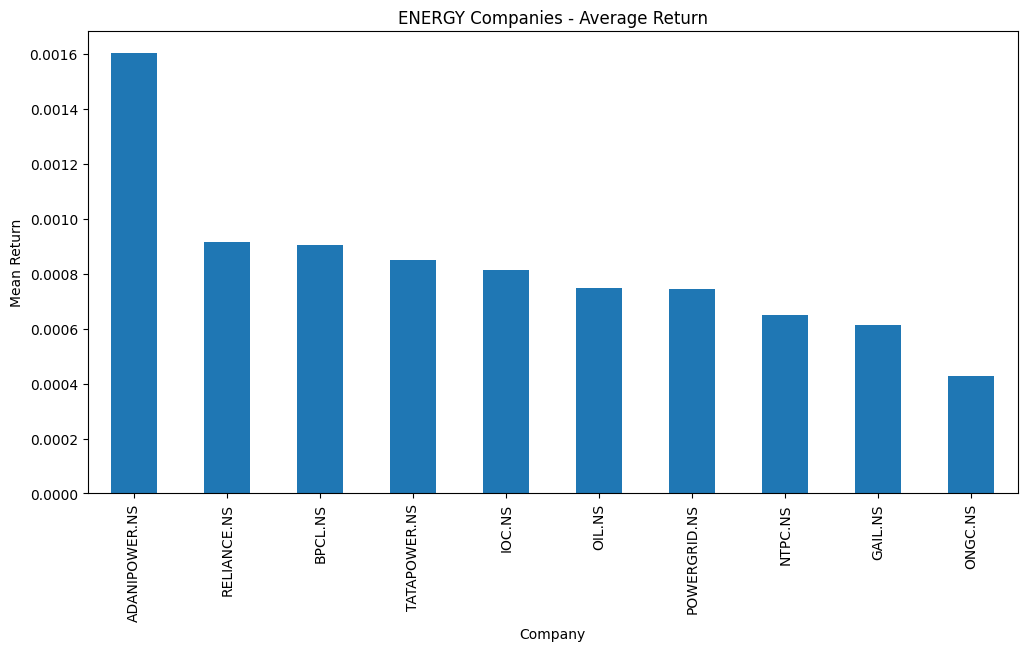

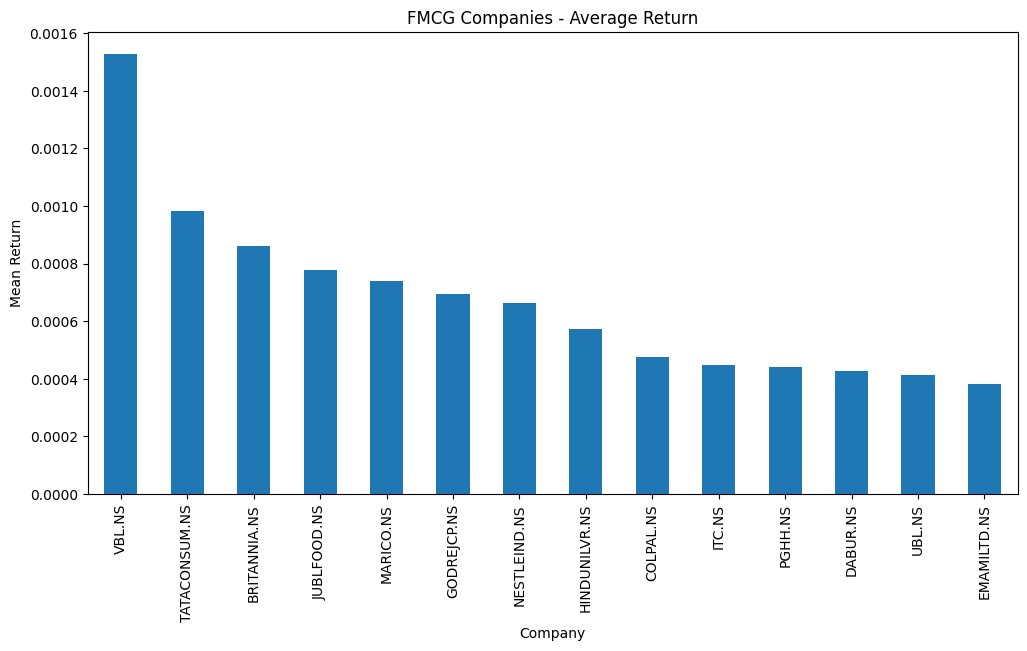

In [17]:
import matplotlib.pyplot as plt

for sector in df["Sector"].unique():

    temp = (
        df[df["Sector"] == sector]
        .groupby("Company")["Return"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12,6))

    temp.plot(kind="bar")

    plt.title(
        f"{sector} Companies - Average Return"
    )

    plt.ylabel("Mean Return")

    plt.show()

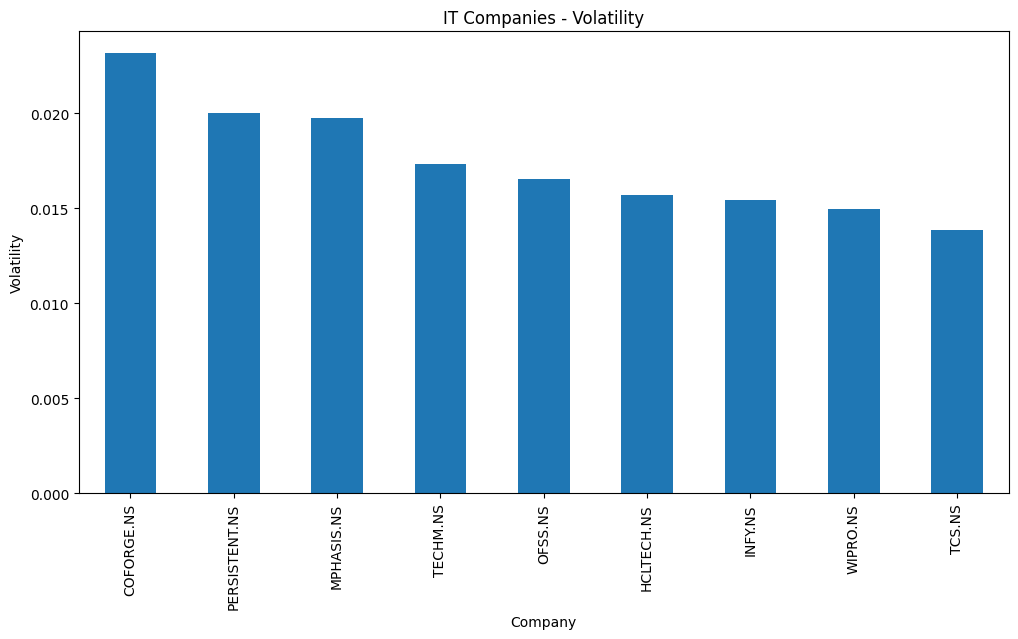

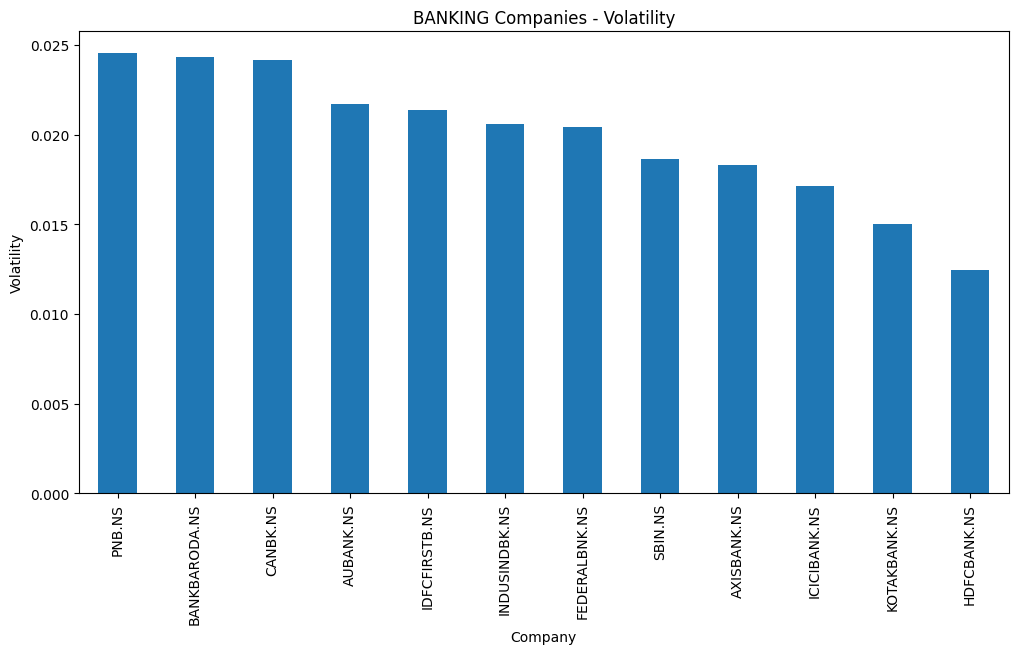

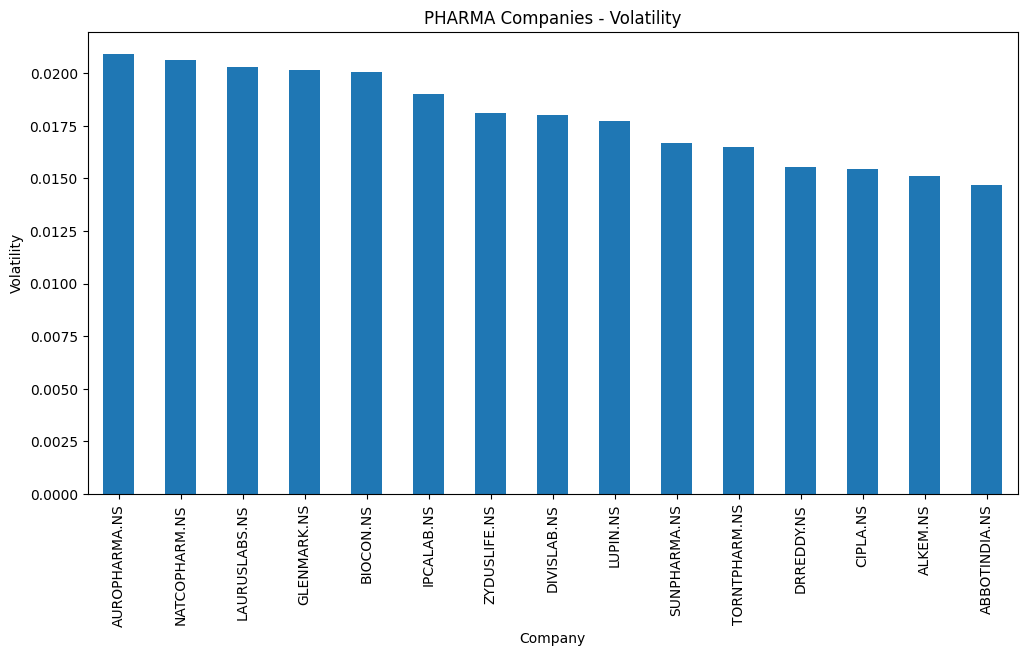

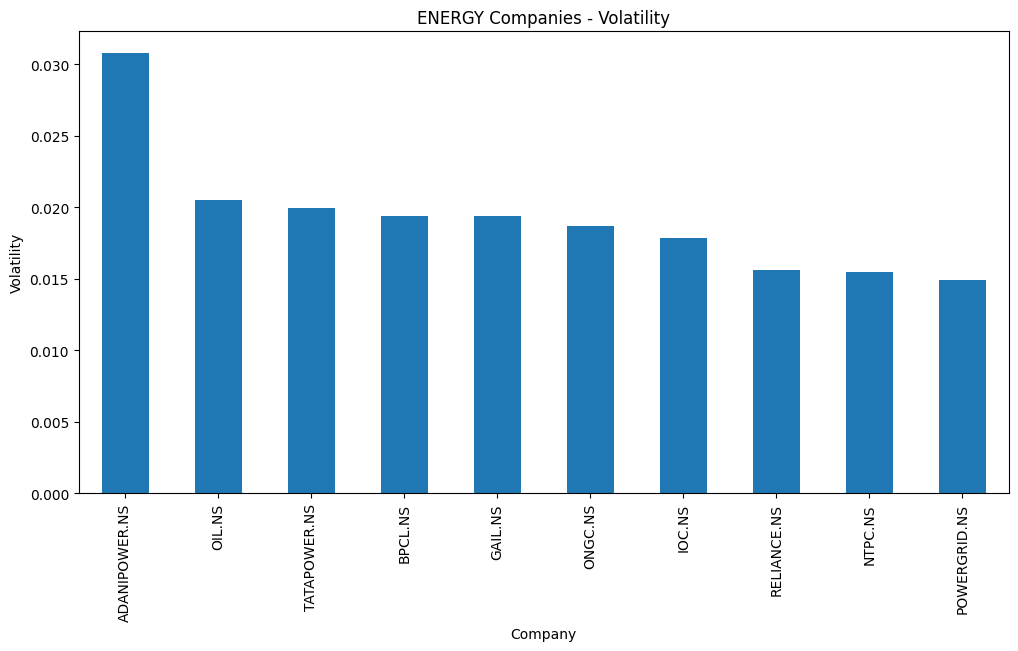

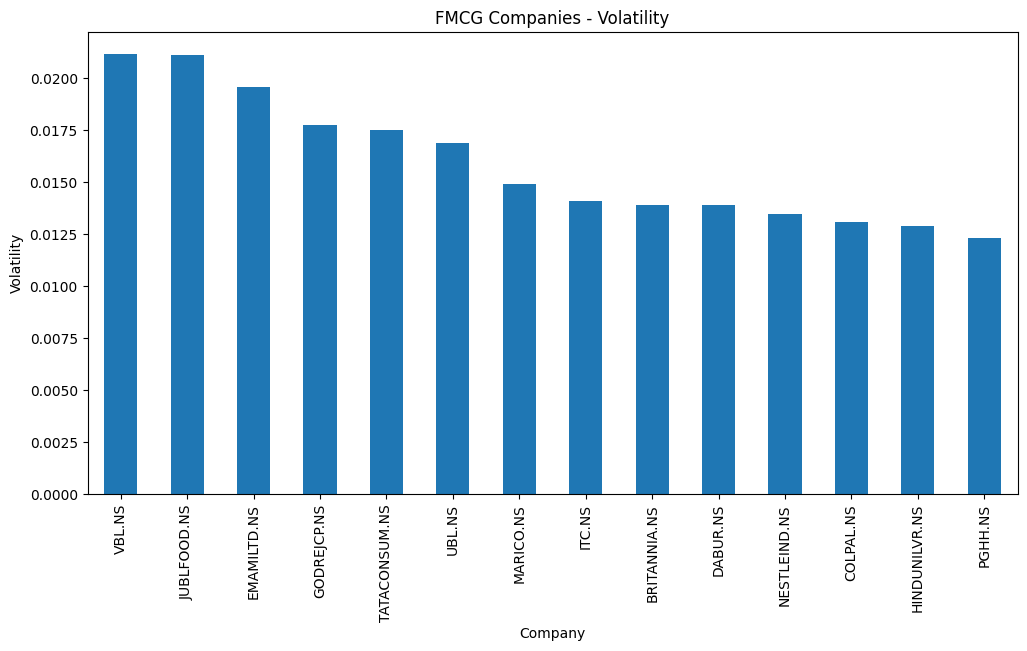

In [18]:
for sector in df["Sector"].unique():

    temp = (
        df[df["Sector"] == sector]
        .groupby("Company")["Volatility_20D"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12,6))

    temp.plot(kind="bar")

    plt.title(
        f"{sector} Companies - Volatility"
    )

    plt.ylabel("Volatility")

    plt.show()

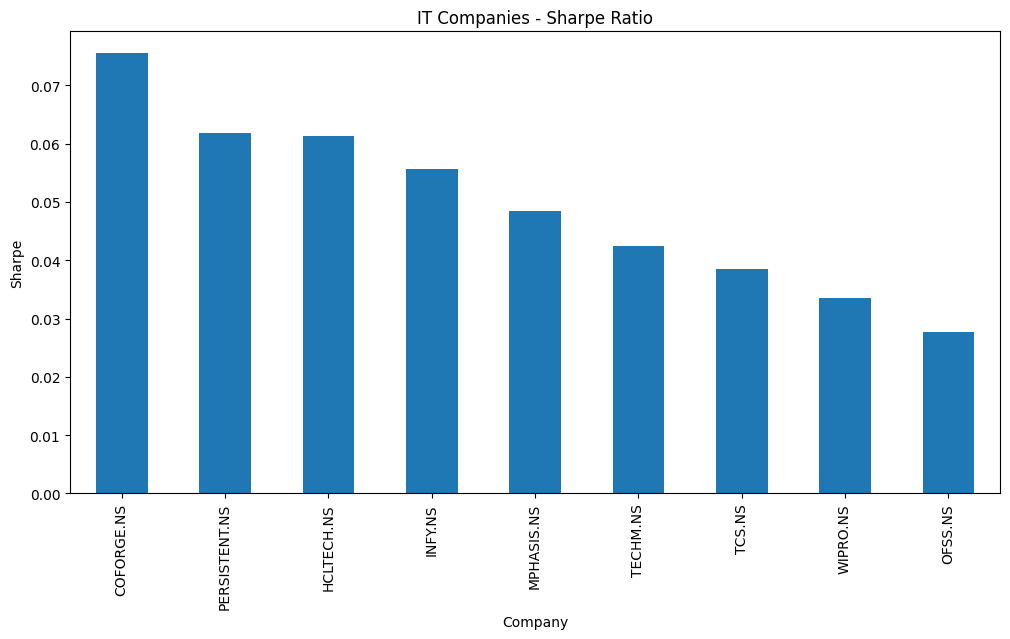

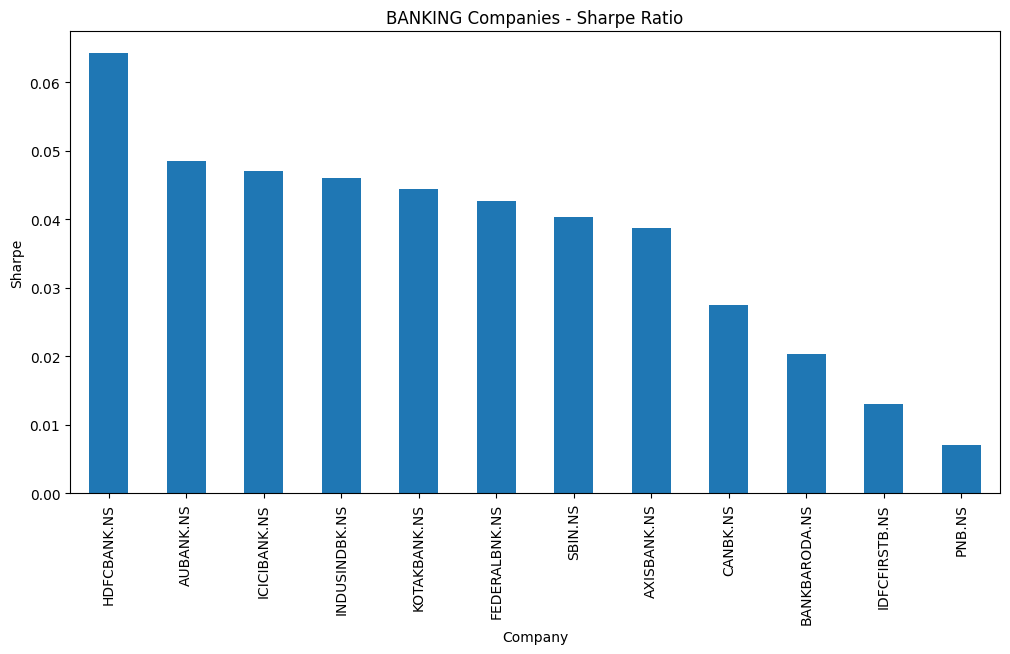

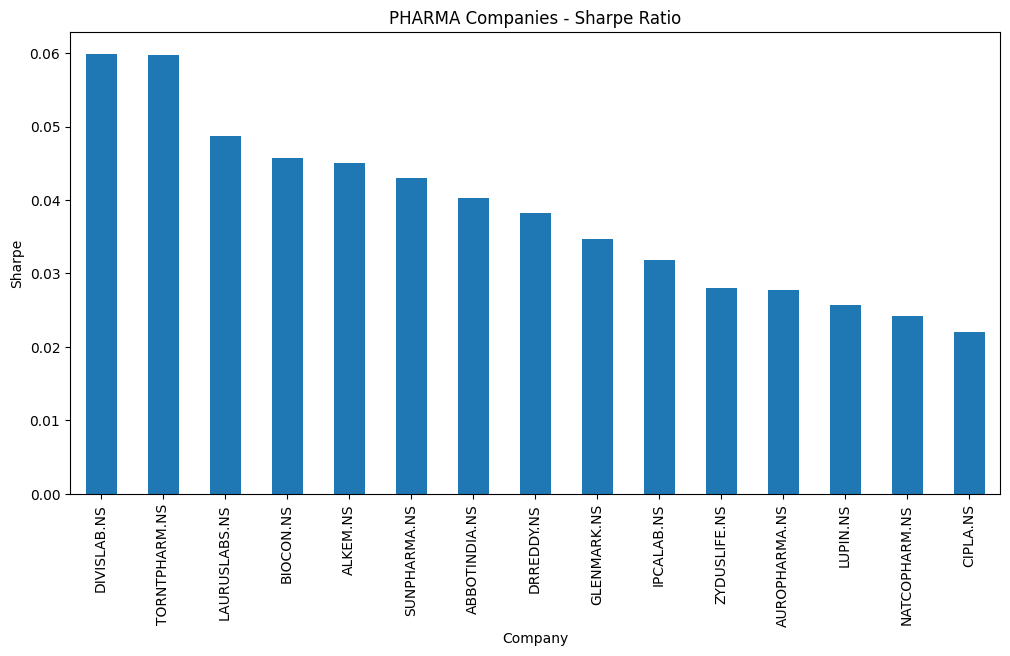

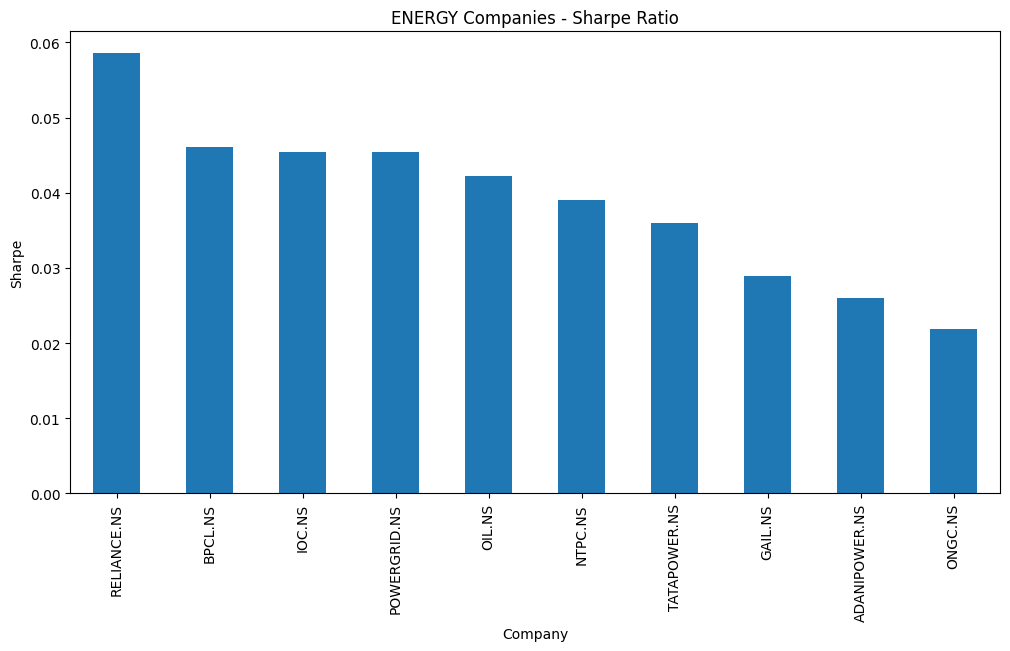

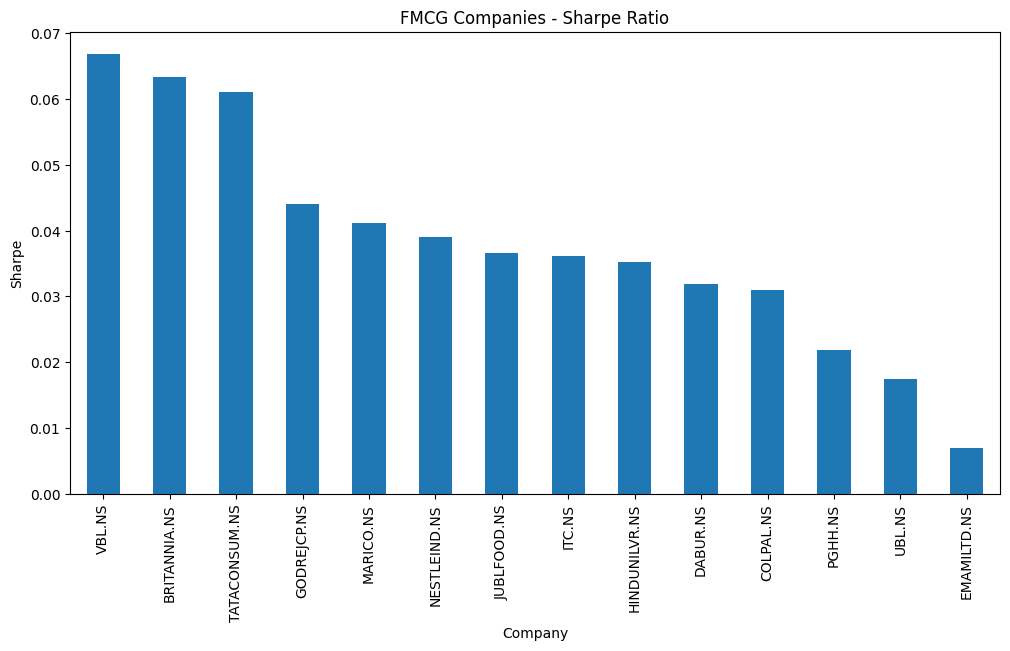

In [19]:
for sector in df["Sector"].unique():

    temp = (
        df[df["Sector"] == sector]
        .groupby("Company")["Sharpe_20D"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12,6))

    temp.plot(kind="bar")

    plt.title(
        f"{sector} Companies - Sharpe Ratio"
    )

    plt.ylabel("Sharpe")

    plt.show()

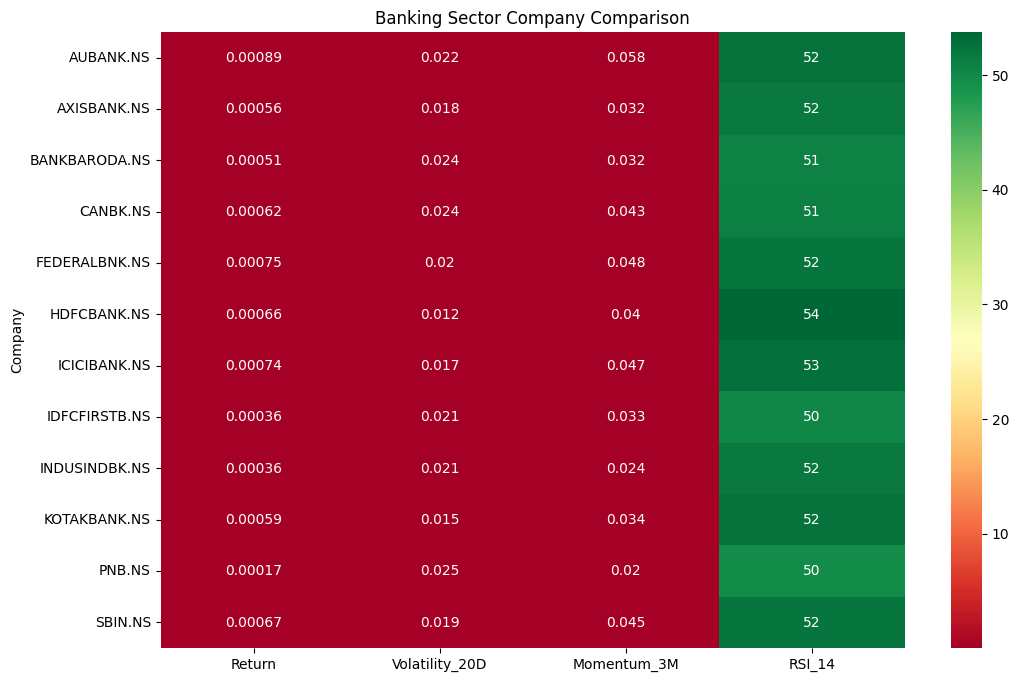

In [20]:
import seaborn as sns

bank = df[df["Sector"] == "BANKING"]

company_features = (

    bank.groupby("Company")

    [["Return",
      "Volatility_20D",
      "Momentum_3M",
      "RSI_14"]]

    .mean()

)

plt.figure(figsize=(12,8))

sns.heatmap(
    company_features,
    annot=True,
    cmap="RdYlGn"
)

plt.title(
    "Banking Sector Company Comparison"
)

plt.show()

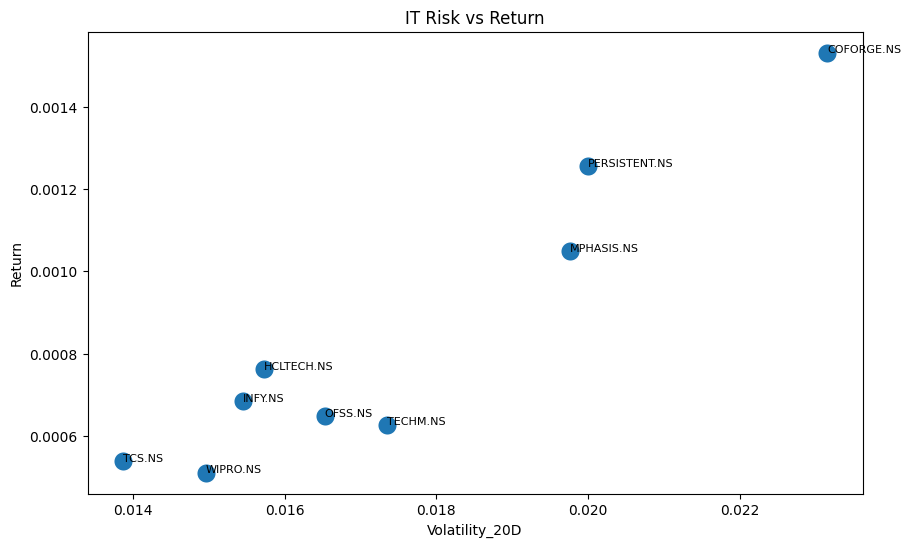

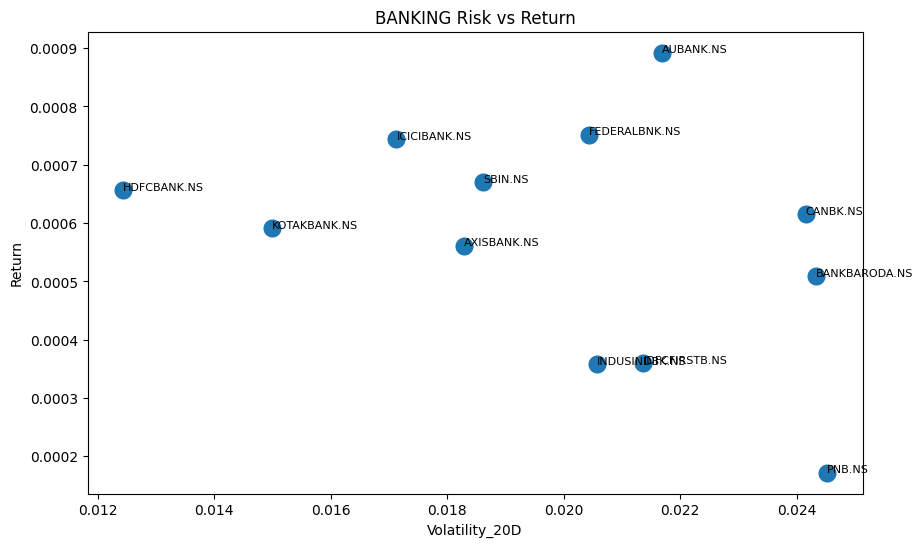

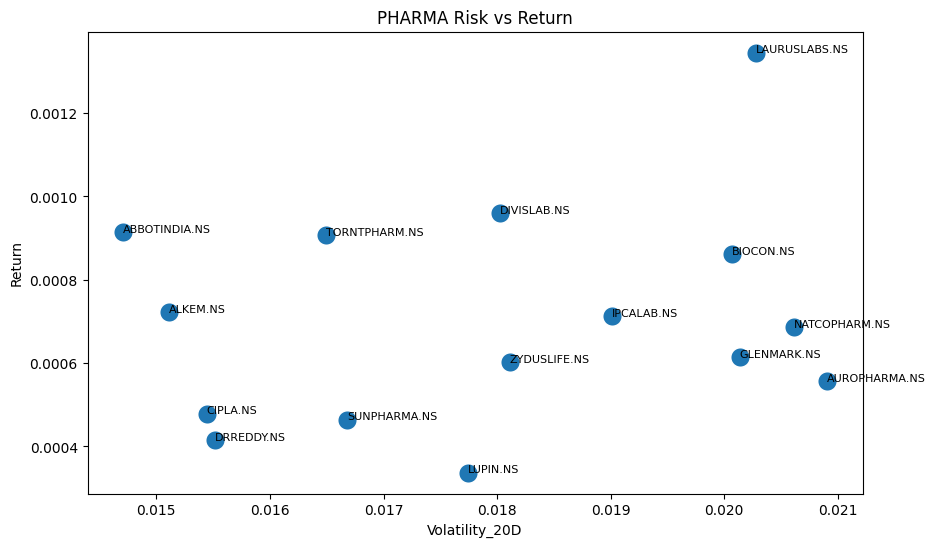

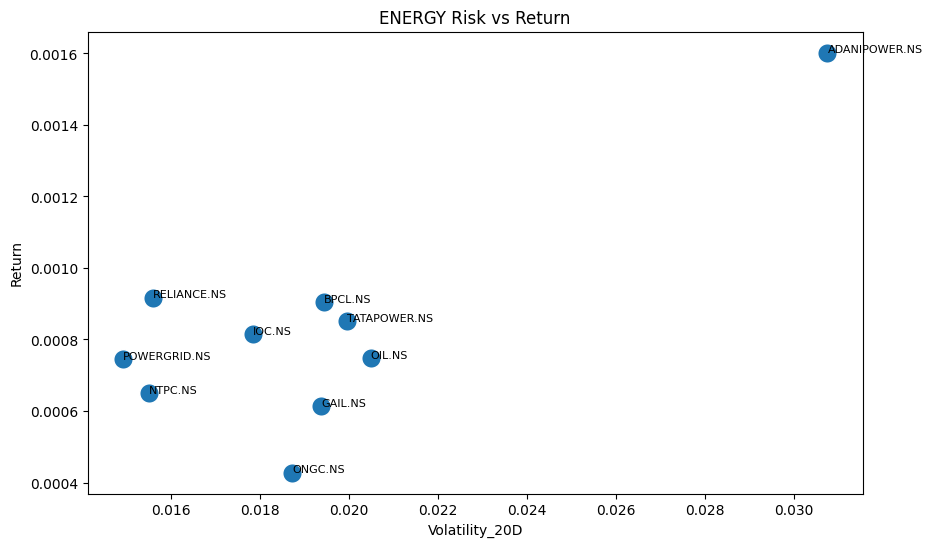

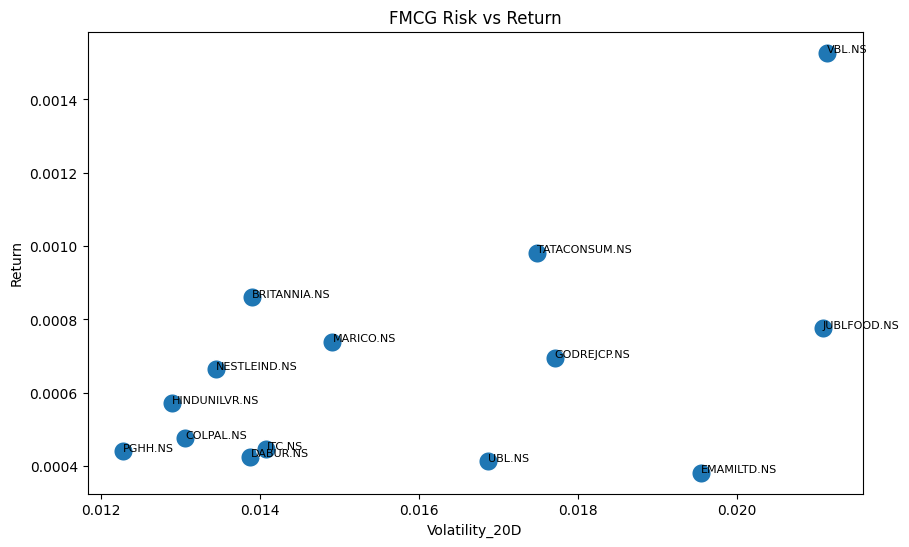

In [21]:
for sector in df["Sector"].unique():

    temp = (

        df[df["Sector"] == sector]

        .groupby("Company")

        .agg({
            "Return":"mean",
            "Volatility_20D":"mean"
        })

    )

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=temp,
        x="Volatility_20D",
        y="Return",
        s=200
    )

    for company,row in temp.iterrows():

        plt.text(
            row["Volatility_20D"],
            row["Return"],
            company,
            fontsize=8
        )

    plt.title(
        f"{sector} Risk vs Return"
    )

    plt.show()

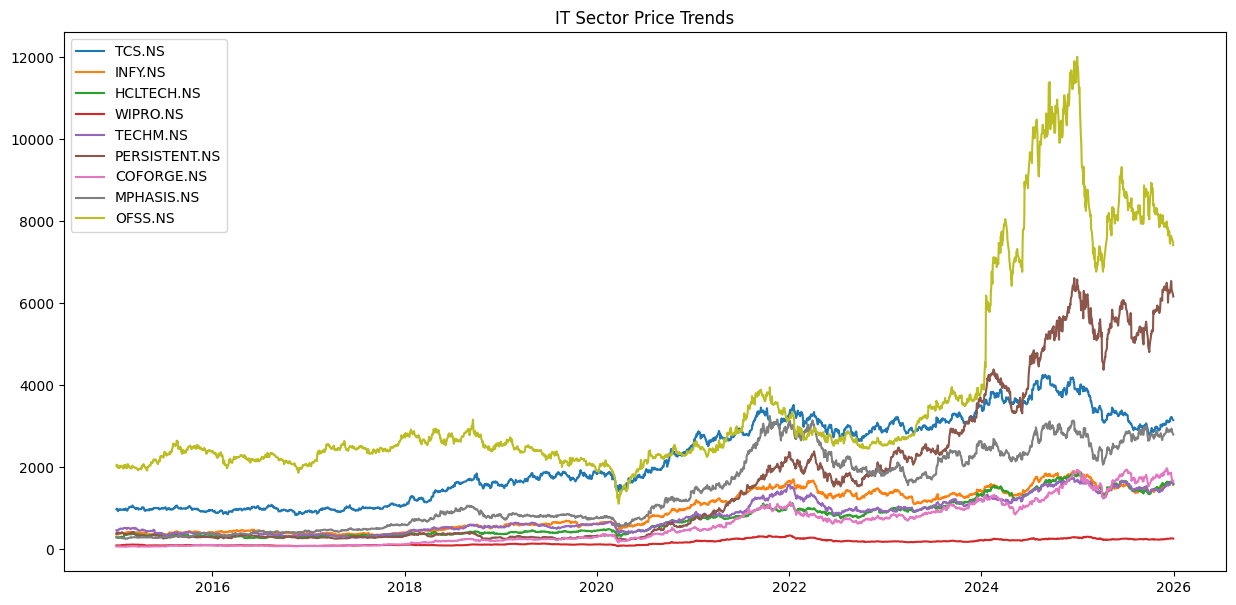

In [22]:
it_df = df[df["Sector"] == "IT"]

plt.figure(figsize=(15,7))

for company in it_df["Company"].unique():

    temp = it_df[
        it_df["Company"] == company
    ]

    plt.plot(
        temp["Date"],
        temp["Close"],
        label=company
    )

plt.legend()

plt.title(
    "IT Sector Price Trends"
)

plt.show()

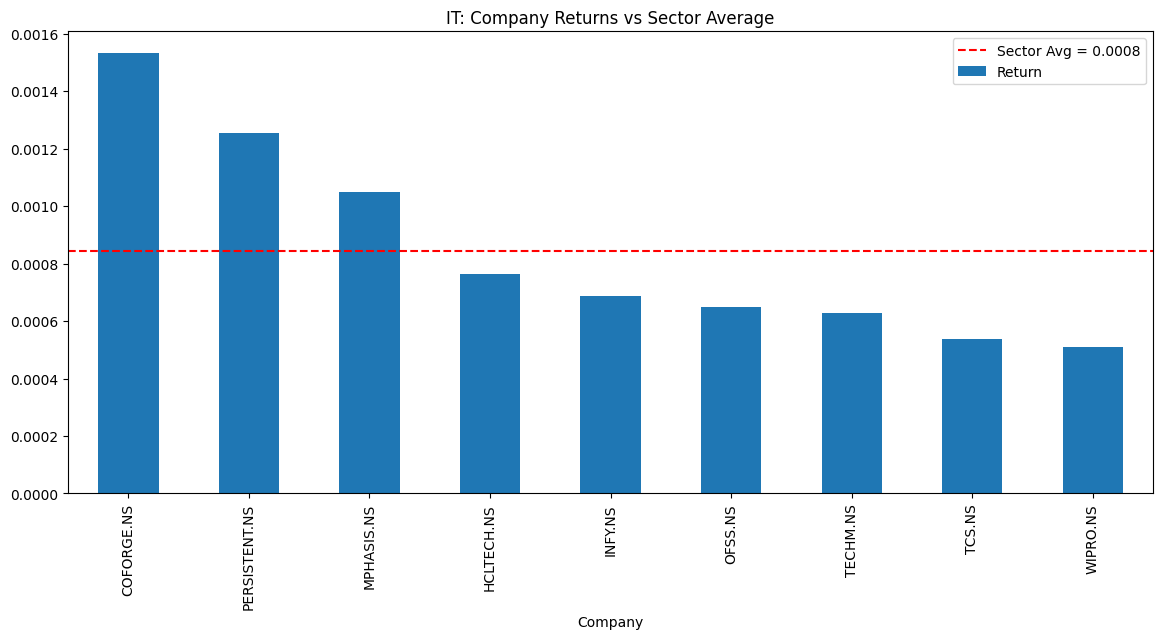

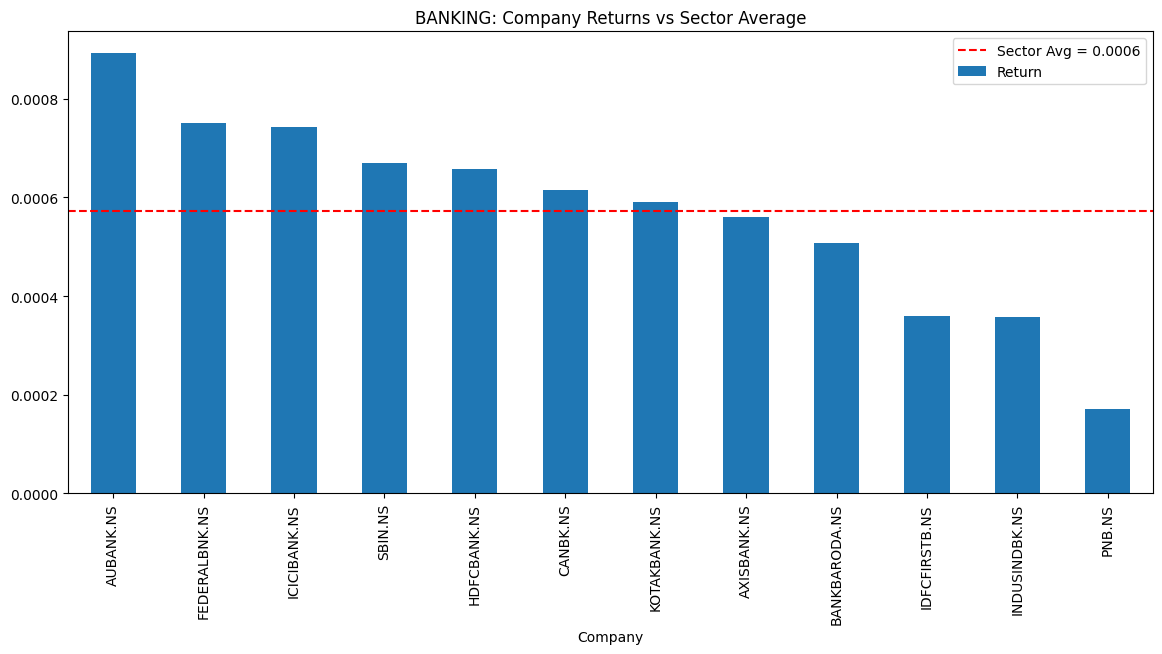

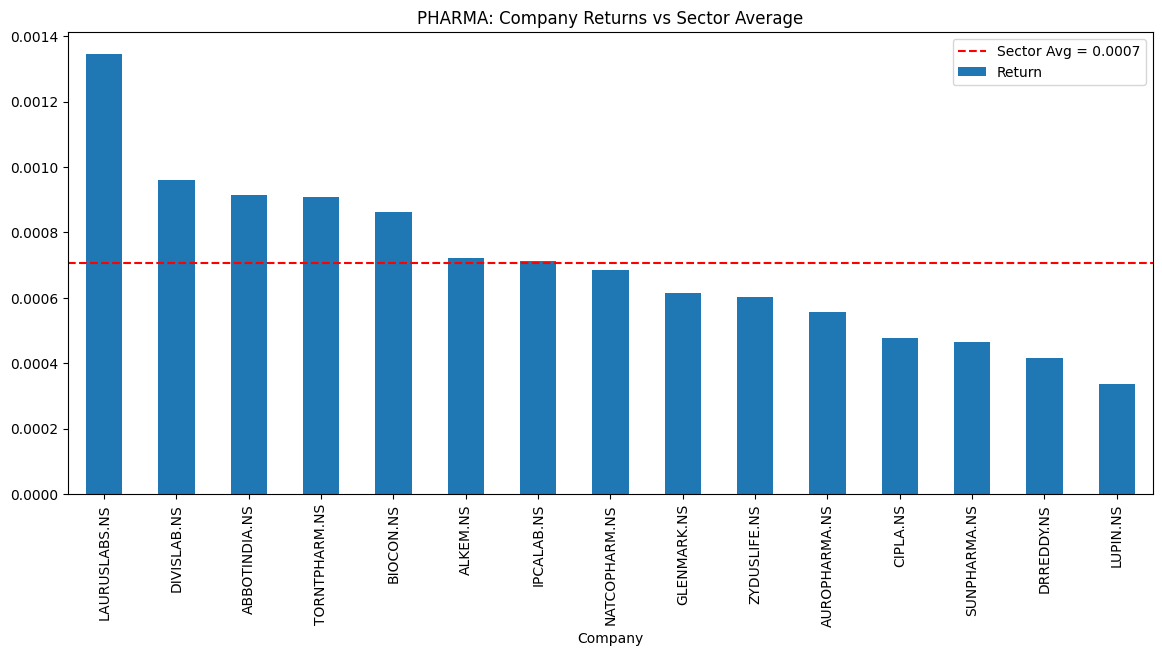

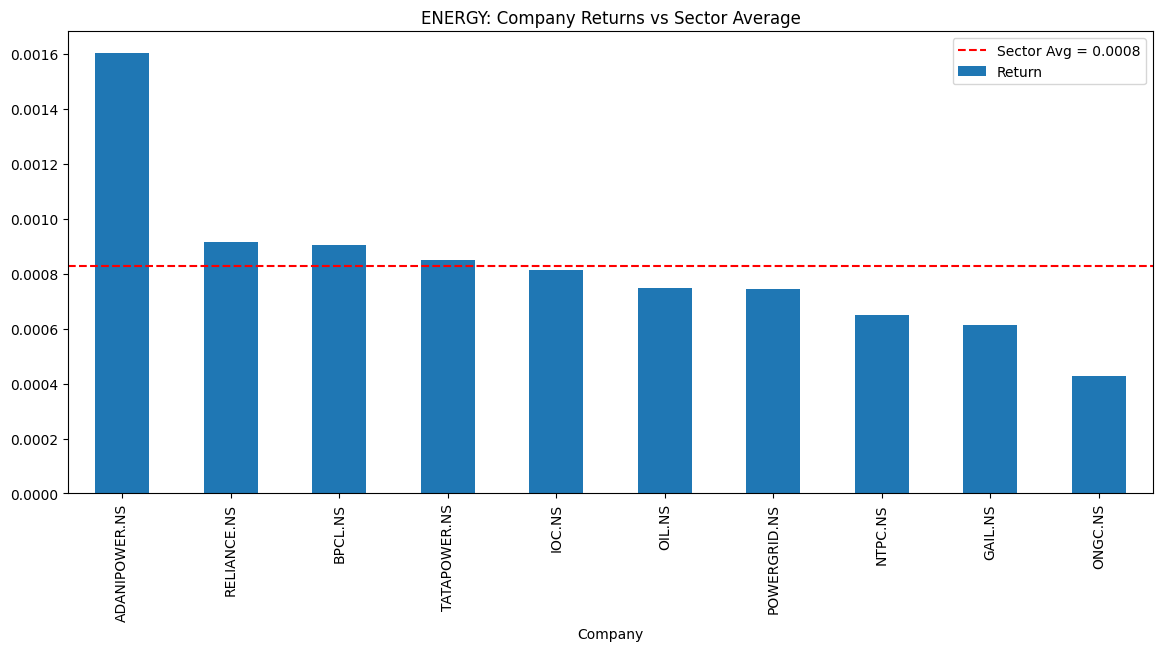

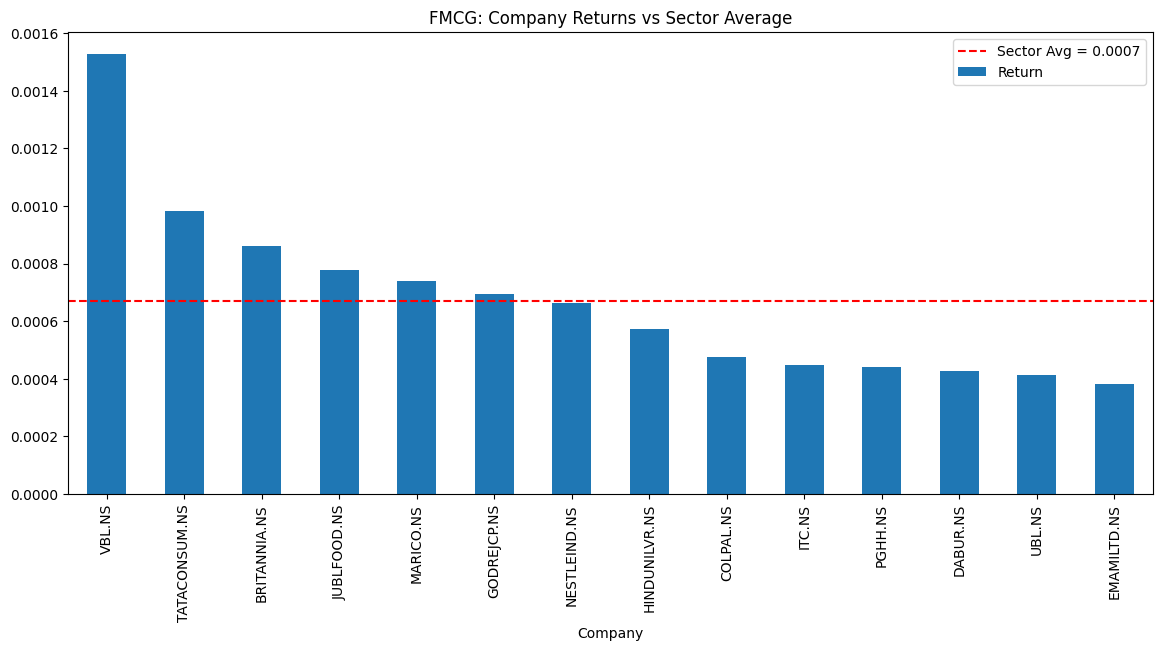

In [23]:
import matplotlib.pyplot as plt

for sector in df["Sector"].unique():

    sector_df = df[df["Sector"] == sector]

    company_return = (
        sector_df.groupby("Company")["Return"]
        .mean()
        .sort_values(ascending=False)
    )

    sector_avg = company_return.mean()

    plt.figure(figsize=(14,6))

    company_return.plot(kind="bar")

    plt.axhline(
        sector_avg,
        color="red",
        linestyle="--",
        label=f"Sector Avg = {sector_avg:.4f}"
    )

    plt.title(f"{sector}: Company Returns vs Sector Average")

    plt.legend()

    plt.show()

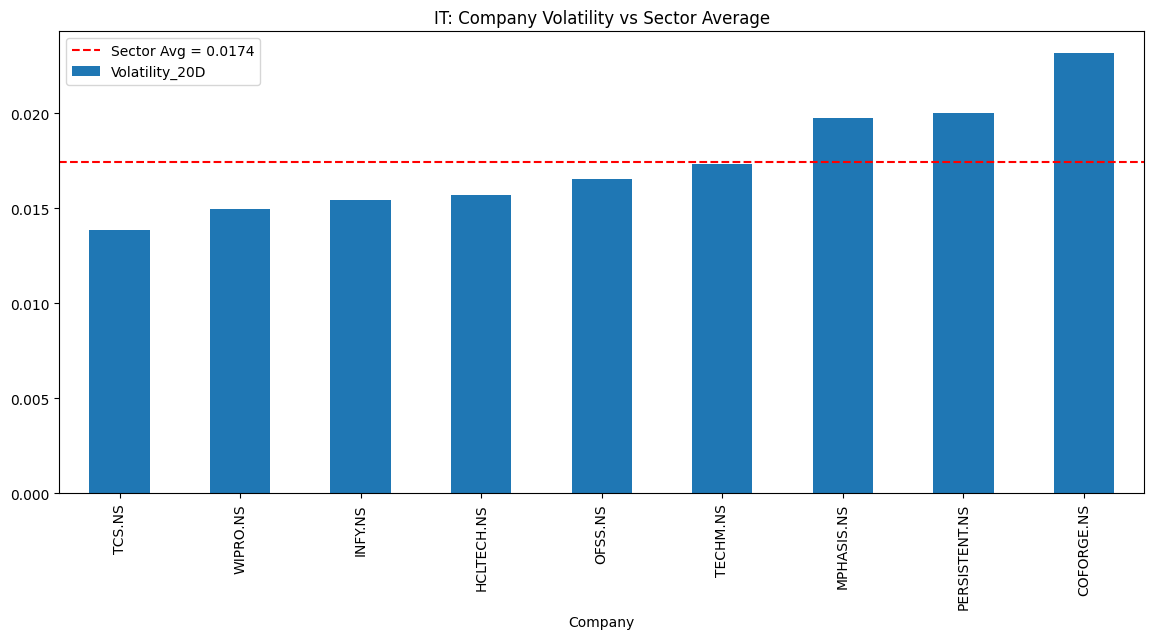

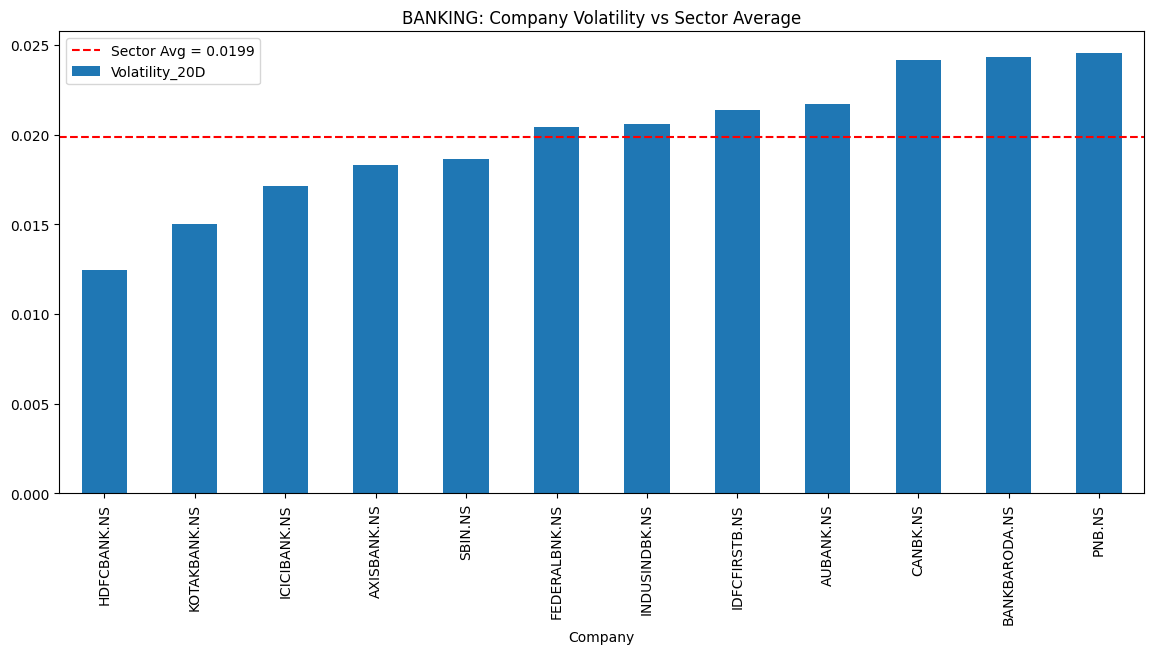

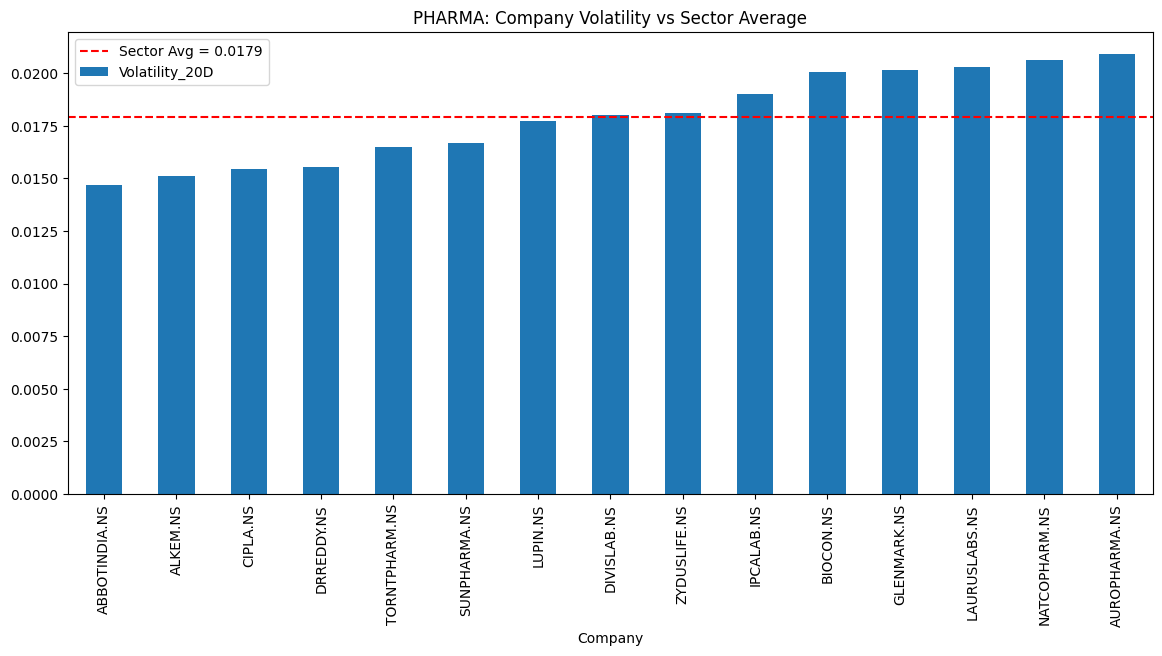

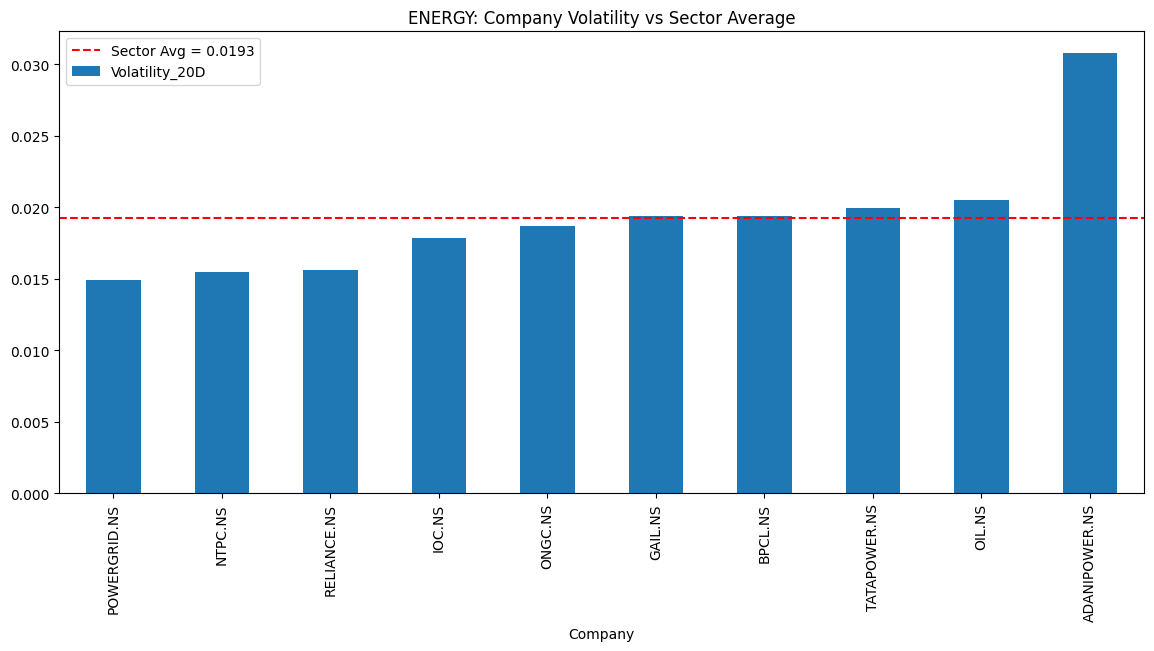

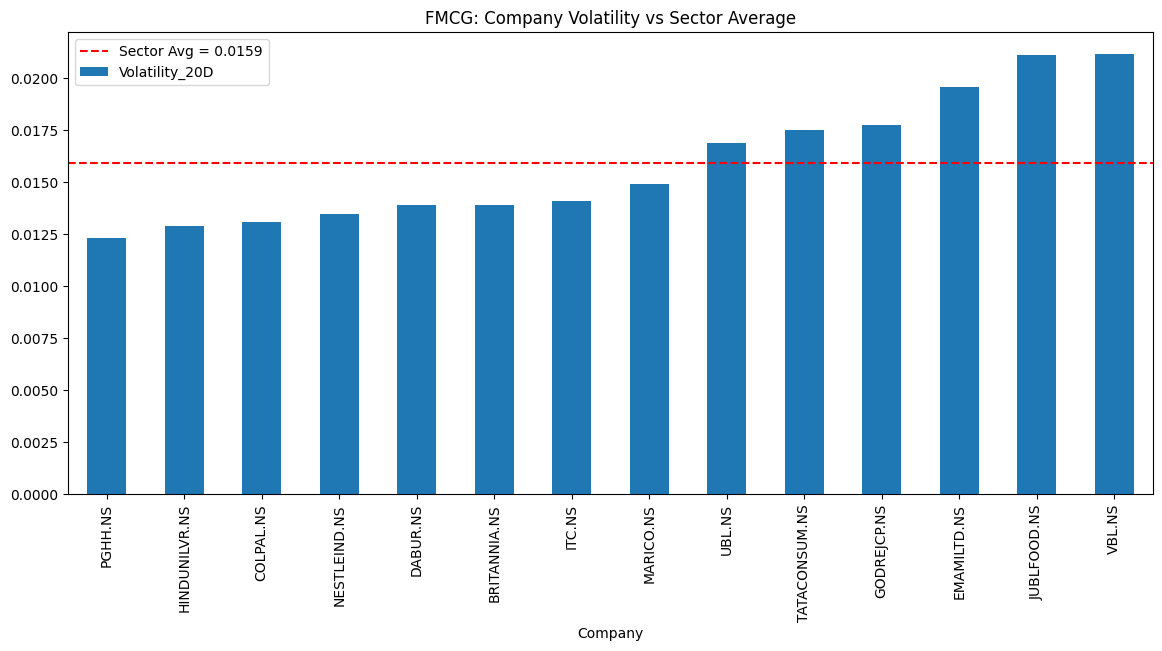

In [24]:
for sector in df["Sector"].unique():

    sector_df = df[df["Sector"] == sector]

    company_vol = (
        sector_df.groupby("Company")["Volatility_20D"]
        .mean()
        .sort_values()
    )

    sector_avg = company_vol.mean()

    plt.figure(figsize=(14,6))

    company_vol.plot(kind="bar")

    plt.axhline(
        sector_avg,
        color="red",
        linestyle="--",
        label=f"Sector Avg = {sector_avg:.4f}"
    )

    plt.title(f"{sector}: Company Volatility vs Sector Average")

    plt.legend()

    plt.show()

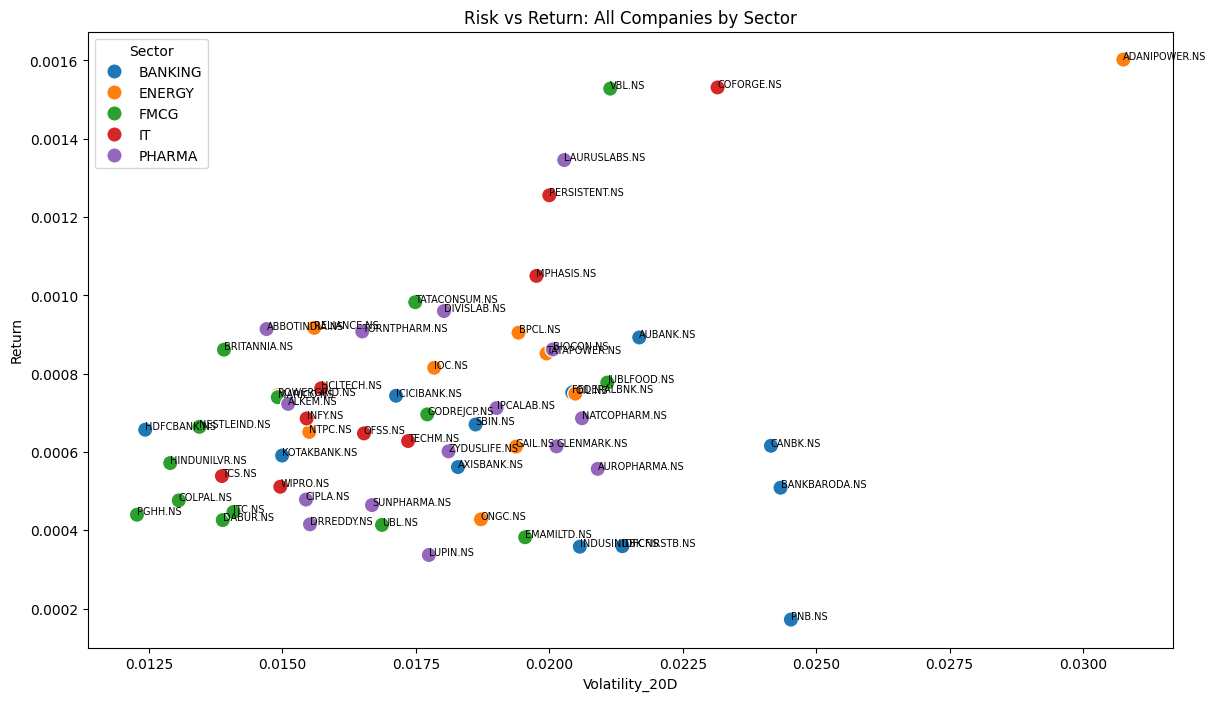

In [25]:
import seaborn as sns

company_stats = (

    df.groupby(["Sector","Company"])

    .agg({
        "Return":"mean",
        "Volatility_20D":"mean"
    })

    .reset_index()

)

plt.figure(figsize=(14,8))

sns.scatterplot(
    data=company_stats,
    x="Volatility_20D",
    y="Return",
    hue="Sector",
    s=120
)

for _, row in company_stats.iterrows():

    plt.text(
        row["Volatility_20D"],
        row["Return"],
        row["Company"],
        fontsize=7
    )

plt.title(
    "Risk vs Return: All Companies by Sector"
)

plt.show()

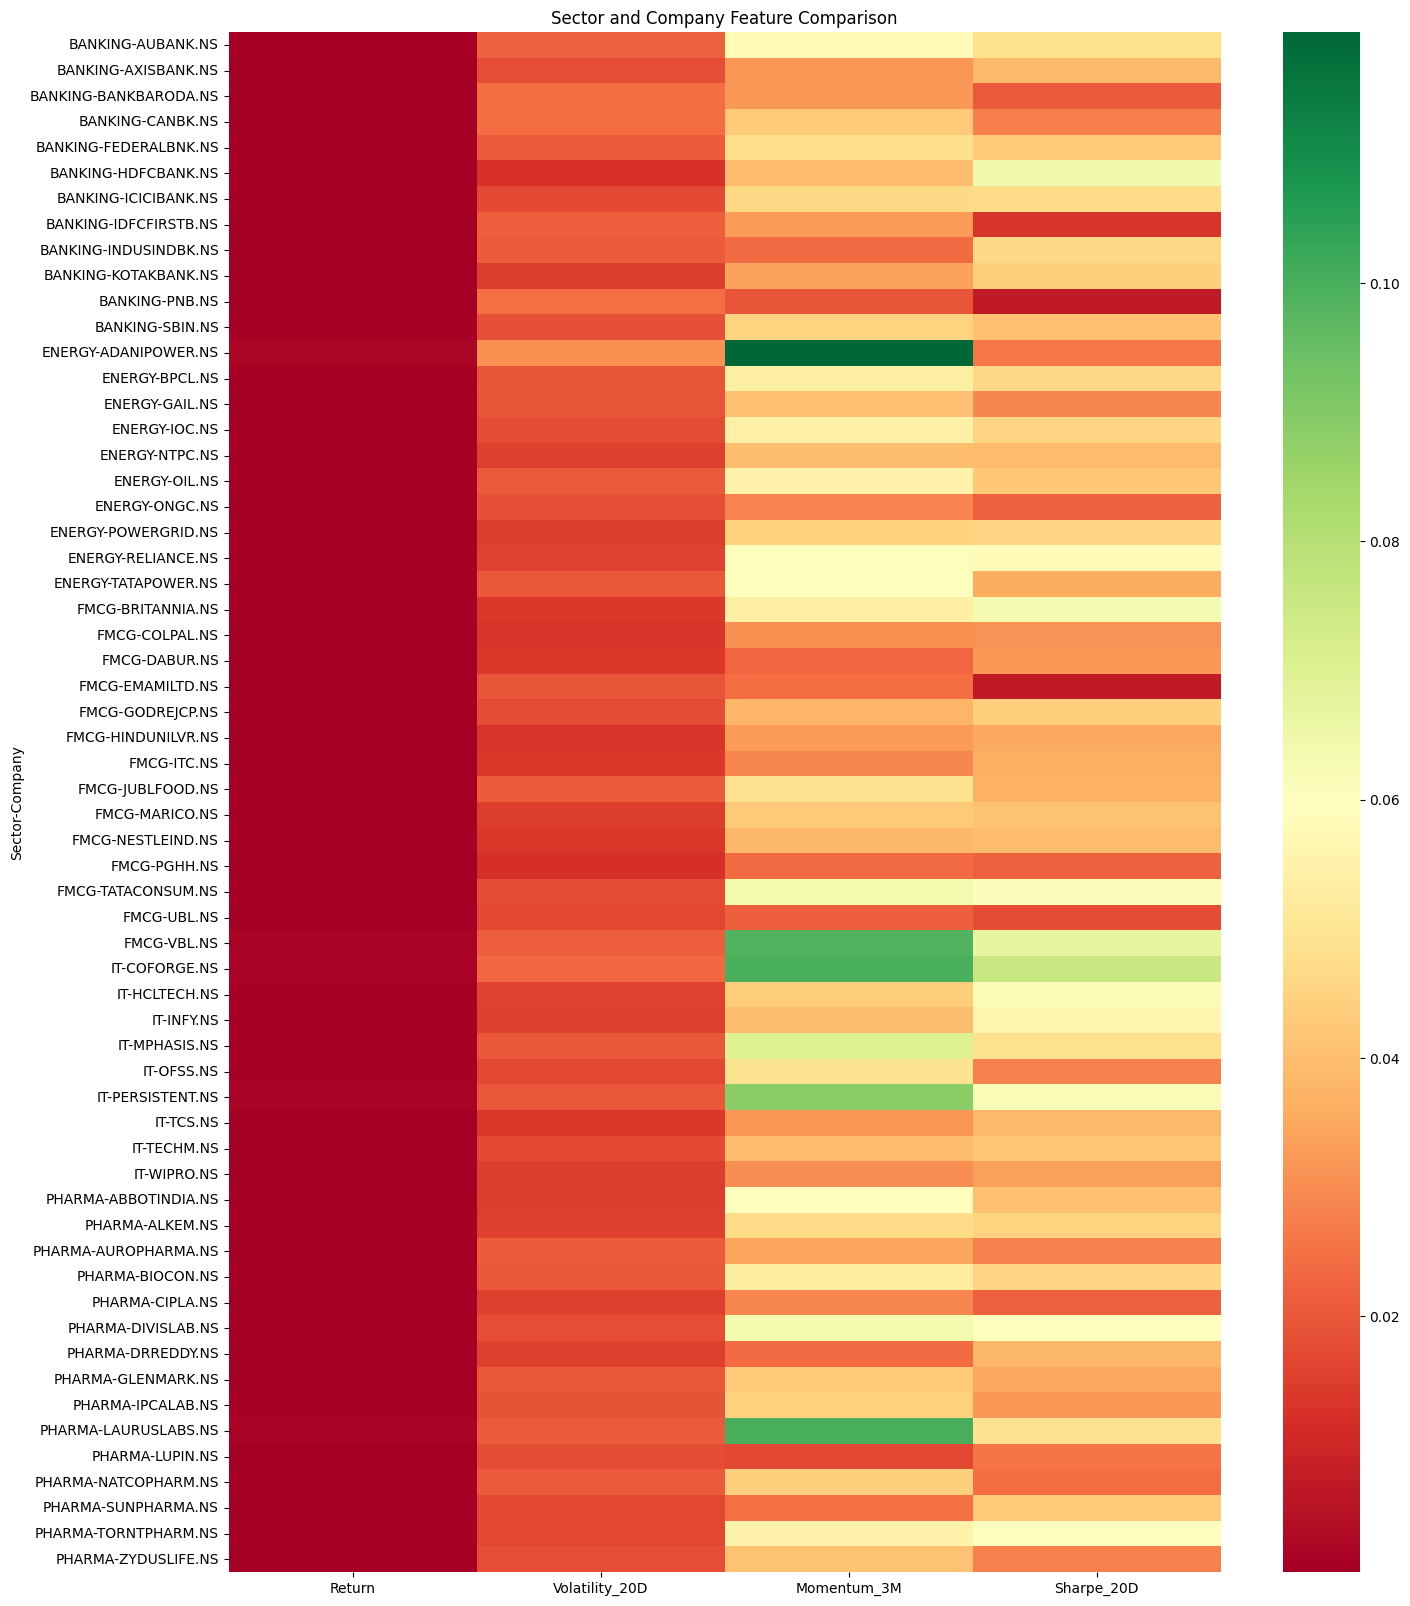

In [26]:
import seaborn as sns

summary = (

    df.groupby(["Sector","Company"])

    [["Return",
      "Volatility_20D",
      "Momentum_3M",
      "Sharpe_20D"]]

    .mean()

)

plt.figure(figsize=(16,20))

sns.heatmap(
    summary,
    cmap="RdYlGn"
)

plt.title(
    "Sector and Company Feature Comparison"
)

plt.show()

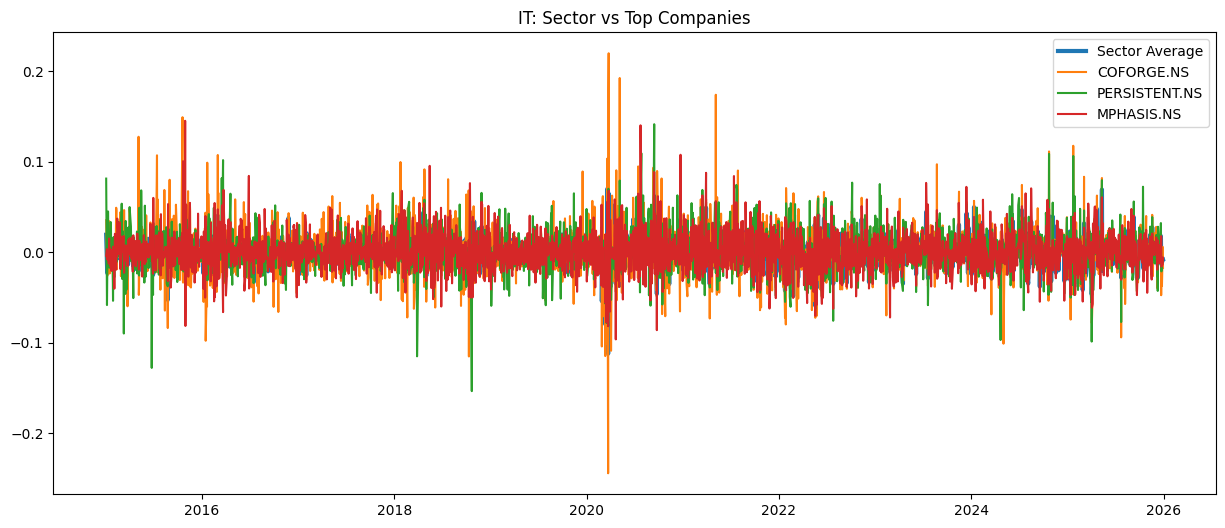

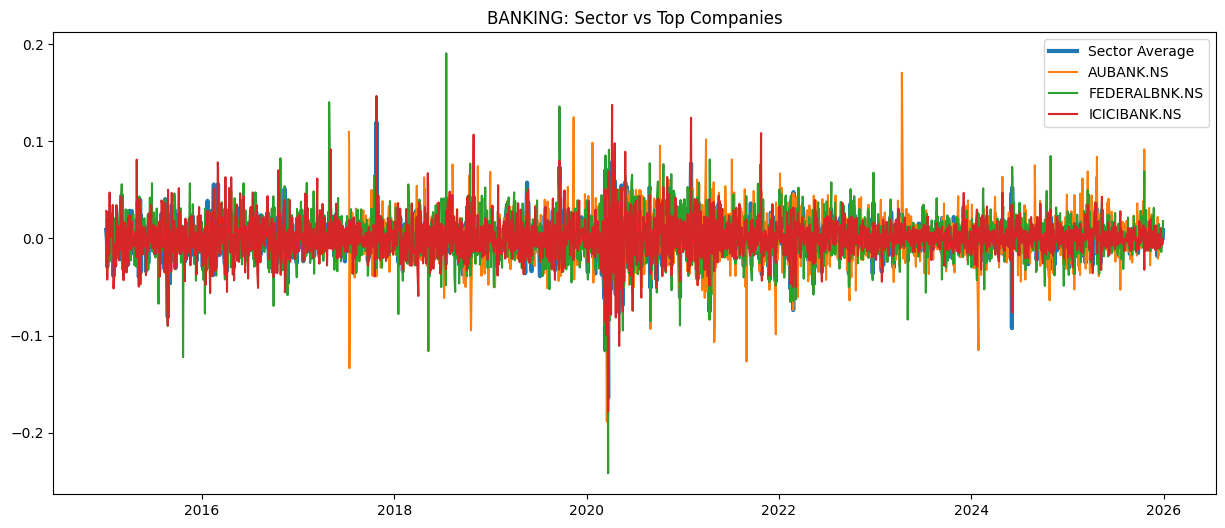

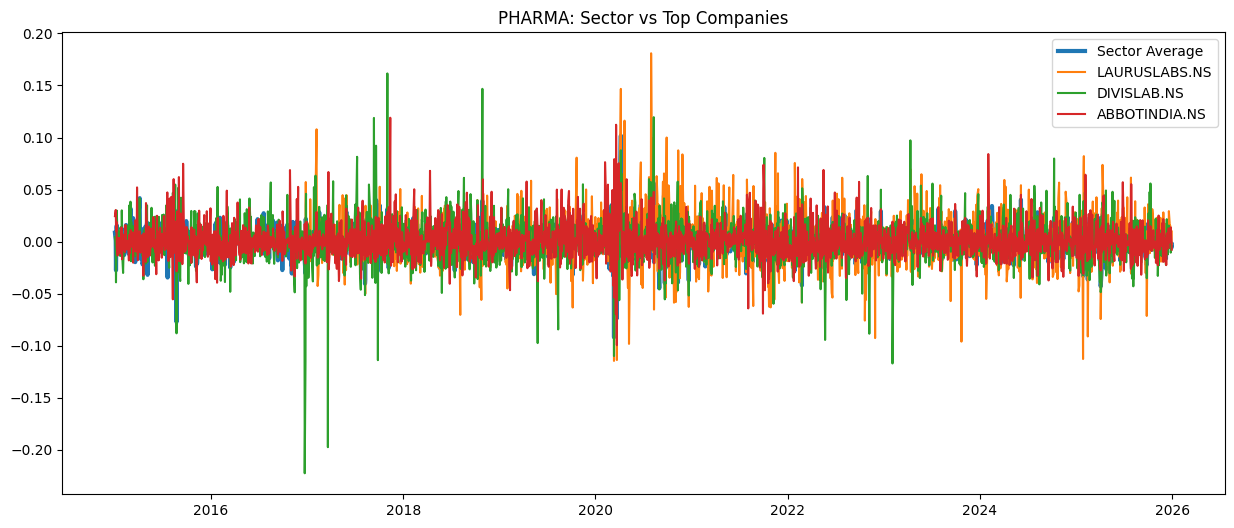

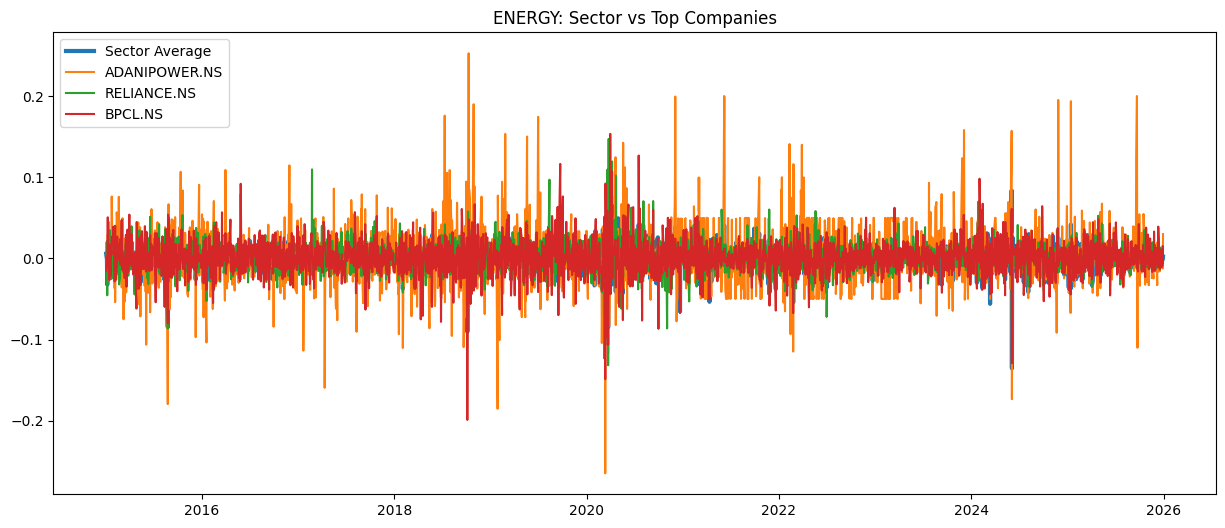

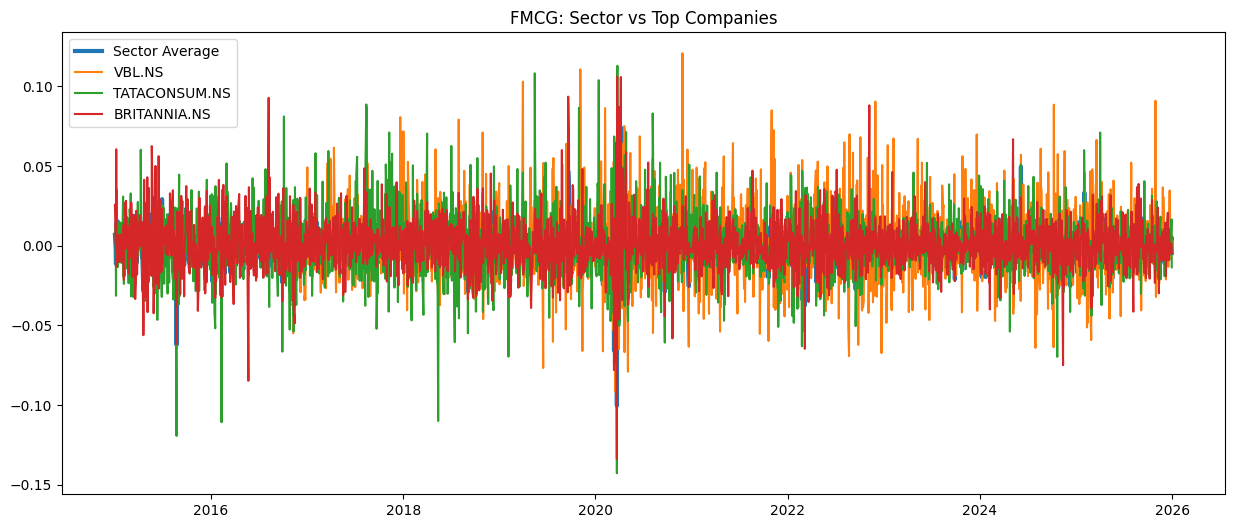

In [27]:
for sector in df["Sector"].unique():

    temp = df[df["Sector"] == sector]

    top3 = (

        temp.groupby("Company")["Return"]

        .mean()

        .sort_values(ascending=False)

        .head(3)

        .index
    )

    plt.figure(figsize=(15,6))

    sector_ts = (
        temp.groupby("Date")["Return"]
        .mean()
    )

    plt.plot(
        sector_ts.index,
        sector_ts.values,
        linewidth=3,
        label="Sector Average"
    )

    for company in top3:

        comp = temp[
            temp["Company"] == company
        ]

        comp_ts = (
            comp.groupby("Date")["Return"]
            .mean()
        )

        plt.plot(
            comp_ts.index,
            comp_ts.values,
            label=company
        )

    plt.legend()

    plt.title(
        f"{sector}: Sector vs Top Companies"
    )

    plt.show()